<div style="text-align:center; font-family:Georgia, serif; background-color:#f5f5f5; padding:10px;">

  <h2 style="margin:0; padding:8px 0;">
     PG NPG Gridworld Analysis (Fox 2016)
  </h2>

  <h3 style="margin:0; padding:6px 0;">
    RL Group Project Part 4
  </h3>

  <h5 style="margin:0; padding:6px 0;">
    Team - Reward Hunters 
  </h5>

</div>

---

> *"In NPG, we don't just follow the gradient — we follow the steepest ascent in the space of distributions, not parameters."*

### Objectives
1. **Environment Exploration** — Visualize the 8×8 GridWorld, blocked states, and trajectory distributions  
2. **Tabular Softmax Policy** — Direct parameterization π(a|s) = exp(θ_{s,a}) / Σ exp(θ_{s,a'})  
3. **Policy Gradient (PG)** — Vanilla REINFORCE with various learning rates  
4. **Natural Policy Gradient (NPG)** — Fisher-preconditioned updates with KL safety constraint δ  
5. **Comparative Analysis** — Convergence, stability, KL dynamics, Fisher matrix conditioning  
6. **Ablation Studies** — Effect of γ, δ, episode length, seeds  
7. **Publication-Grade Visualizations** — Seaborn, matplotlib, heatmaps, violin plots, and more

---

In [15]:
# ============================================================
# CELL 1: Imports & Setup
# ============================================================
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyArrowPatch, Rectangle, Circle
from matplotlib.collections import LineCollection
import seaborn as sns
from scipy.ndimage import gaussian_filter
from scipy.stats import sem
import warnings
import sys
import os
import time
from copy import deepcopy
from collections import defaultdict
import itertools

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Aesthetics ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':   '#0F1117',
    'axes.facecolor':     '#161B22',
    'axes.edgecolor':     '#30363D',
    'axes.labelcolor':    '#E6EDF3',
    'xtick.color':        '#8B949E',
    'ytick.color':        '#8B949E',
    'text.color':         '#E6EDF3',
    'grid.color':         '#21262D',
    'grid.linewidth':     0.6,
    'axes.titlesize':     13,
    'axes.labelsize':     11,
    'xtick.labelsize':    9,
    'ytick.labelsize':    9,
    'legend.fontsize':    9,
    'font.family':        'monospace',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
})
sns.set_theme(style='dark', rc={
    'figure.facecolor': '#0F1117',
    'axes.facecolor':   '#161B22',
})

# Custom color palettes
GOLD   = '#F0C030'
TEAL   = '#00D4AA'
CORAL  = '#FF6B6B'
BLUE   = '#4DAAFF'
PURPLE = '#B97EFF'
WHITE  = '#E6EDF3'
GRAY   = '#8B949E'

PALETTE = [TEAL, CORAL, GOLD, BLUE, PURPLE]

# GridWorld colormap: deep blue → vibrant orange
GW_CMAP = LinearSegmentedColormap.from_list(
    'gw', ['#0D1B2A', '#1B4F72', '#2E86C1', '#F39C12', '#E74C3C'])

print('✅ Imports complete')


✅ Imports complete


In [16]:
# ============================================================
# CELL 2: Load GridWorld Environment
# ============================================================
import importlib.util, sys, os

# Robust import regardless of working directory
env_path = 'gridworld_env.py'
if not os.path.exists(env_path):
    env_path = os.path.join(os.path.dirname(os.path.abspath('.')), 'gridworld_env.py')

spec = importlib.util.spec_from_file_location('gridworld_env', env_path)
mod  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
GridWorldEnv = mod.GridWorldEnv

env = GridWorldEnv()

# ── Environment constants ──────────────────────────────────
N_STATES  = 64          # 8×8 grid
N_ACTIONS = 9           # 0=N, 1=NE, …, 8=Stay
GRID_SIZE = 8
TERMINAL  = (4, 4)      # row, col
TERMINAL_IDX = 4*8 + 4  # = 36

INV_STATES = env.inv_state   # list of [row,col]
INV_IDX = set(r*8+c for r,c in INV_STATES)

ACTION_SYMBOLS = ['↑','↗','→','↘','↓','↙','←','↖','•']
ACTION_NAMES   = ['N','NE','E','SE','S','SW','W','NW','Stay']
ACTION_DELTAS  = {0:(-1,0),1:(-1,1),2:(0,1),3:(1,1),
                  4:(1,0), 5:(1,-1),6:(0,-1),7:(-1,-1),8:(0,0)}

def state_to_idx(row, col): return row * 8 + col
def idx_to_state(idx): return divmod(idx, 8)

VALID_STATES = [i for i in range(N_STATES)
                if i not in INV_IDX and i != TERMINAL_IDX]

print(f'✅ Environment loaded')
print(f'   Valid states (non-blocked, non-terminal): {len(VALID_STATES)}')
print(f'   Blocked states: {len(INV_STATES)}')
print(f'   Terminal state: row={TERMINAL[0]}, col={TERMINAL[1]}, idx={TERMINAL_IDX}')

GridWorldEnv (Fox2016) Loaded...
✅ Environment loaded
   Valid states (non-blocked, non-terminal): 48
   Blocked states: 15
   Terminal state: row=4, col=4, idx=36


In [17]:
import os
print(f'Current Working Directory: {os.getcwd()}')

Current Working Directory: /content


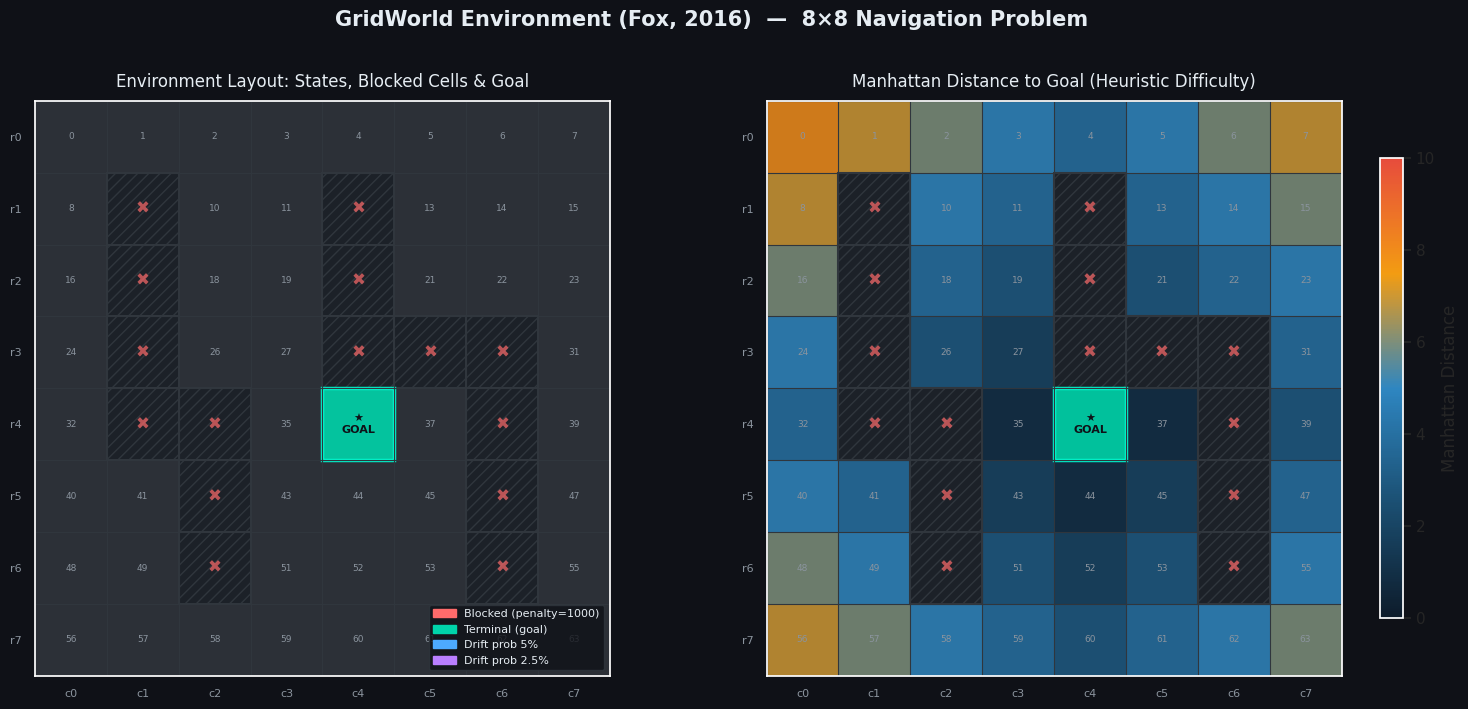

Figure saved: 01_gridworld_map.png


In [18]:
# ============================================================
# CELL 3: GridWorld Map Visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#0F1117')
fig.suptitle('GridWorld Environment (Fox, 2016)  —  8×8 Navigation Problem',
             fontsize=15, color=WHITE, y=1.01, fontweight='bold')

def draw_grid(ax, title, heat_matrix=None, cmap=GW_CMAP, vmin=None, vmax=None):
    ax.set_facecolor('#161B22')
    ax.set_title(title, color=WHITE, pad=10, fontsize=12)

    if heat_matrix is not None:
        im = ax.imshow(heat_matrix, cmap=cmap, vmin=vmin, vmax=vmax,
                       aspect='equal', origin='upper', alpha=0.85)
    else:
        base = np.zeros((8, 8))
        ax.imshow(base, cmap='Blues', vmin=0, vmax=1,
                  aspect='equal', origin='upper', alpha=0.1)

    # Grid lines
    for x in range(9):
        ax.axhline(x - 0.5, color='#30363D', lw=0.8)
        ax.axvline(x - 0.5, color='#30363D', lw=0.8)

    # Blocked cells — dark hatched
    for r, c in INV_STATES:
        rect = Rectangle((c-0.5, r-0.5), 1, 1,
                          facecolor='#1C2128', edgecolor='#30363D',
                          linewidth=1.5, hatch='///')
        ax.add_patch(rect)
        ax.text(c, r, '✖', ha='center', va='center',
                color='#FF6B6B', fontsize=12, alpha=0.7)

    # Terminal cell
    tr, tc = TERMINAL
    rect = Rectangle((tc-0.5, tr-0.5), 1, 1,
                      facecolor='#00D4AA', edgecolor='#00FFD4',
                      linewidth=2.5, alpha=0.9)
    ax.add_patch(rect)
    ax.text(tc, tr, '★\nGOAL', ha='center', va='center',
            color='#0F1117', fontsize=8, fontweight='bold')

    # State indices
    for r in range(8):
        for c in range(8):
            if [r, c] not in INV_STATES and (r, c) != TERMINAL:
                ax.text(c, r, str(r*8+c), ha='center', va='center',
                        color='#8B949E', fontsize=6.5)

    ax.set_xlim(-0.5, 7.5)
    ax.set_ylim(7.5, -0.5)
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))
    ax.set_xticklabels([f'c{i}' for i in range(8)], color=GRAY, fontsize=8)
    ax.set_yticklabels([f'r{i}' for i in range(8)], color=GRAY, fontsize=8)
    return ax

# Panel 1: Bare map
ax1 = draw_grid(axes[0], 'Environment Layout: States, Blocked Cells & Goal')

# Annotate stochastic drift
drift_probs = [
    ((-1,0),  0.050, '5%',  '#4DAAFF'),
    ((-1,1),  0.025, '2.5%','#B97EFF'),
    ((0,1),   0.050, '5%',  '#4DAAFF'),
    ((1,1),   0.025, '2.5%','#B97EFF'),
    ((1,0),   0.050, '5%',  '#4DAAFF'),
    ((1,-1),  0.025, '2.5%','#B97EFF'),
    ((0,-1),  0.050, '5%',  '#4DAAFF'),
    ((-1,-1), 0.025, '2.5%','#B97EFF'),
]
legend_patches = [
    mpatches.Patch(color='#FF6B6B', label='Blocked (penalty=1000)'),
    mpatches.Patch(color='#00D4AA', label='Terminal (goal)'),
    mpatches.Patch(color='#4DAAFF', label='Drift prob 5%'),
    mpatches.Patch(color='#B97EFF', label='Drift prob 2.5%'),
]
axes[0].legend(handles=legend_patches, loc='lower right',
               facecolor='#0F1117', edgecolor='#30363D',
               labelcolor=WHITE, fontsize=8)

# Panel 2: Distance-to-goal heatmap (Manhattan)
dist_mat = np.full((8, 8), np.nan)
for r in range(8):
    for c in range(8):
        if [r, c] not in INV_STATES:
            dist_mat[r, c] = abs(r - TERMINAL[0]) + abs(c - TERMINAL[1])

ax2 = draw_grid(axes[1],
    'Manhattan Distance to Goal (Heuristic Difficulty)',
    heat_matrix=dist_mat, cmap=GW_CMAP, vmin=0, vmax=10)
plt.colorbar(
    plt.cm.ScalarMappable(cmap=GW_CMAP,
        norm=plt.Normalize(0, 10)),
    ax=ax2, shrink=0.8, label='Manhattan Distance')

fig.tight_layout()
plt.savefig('01_gridworld_map.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()
print('Figure saved: 01_gridworld_map.png')

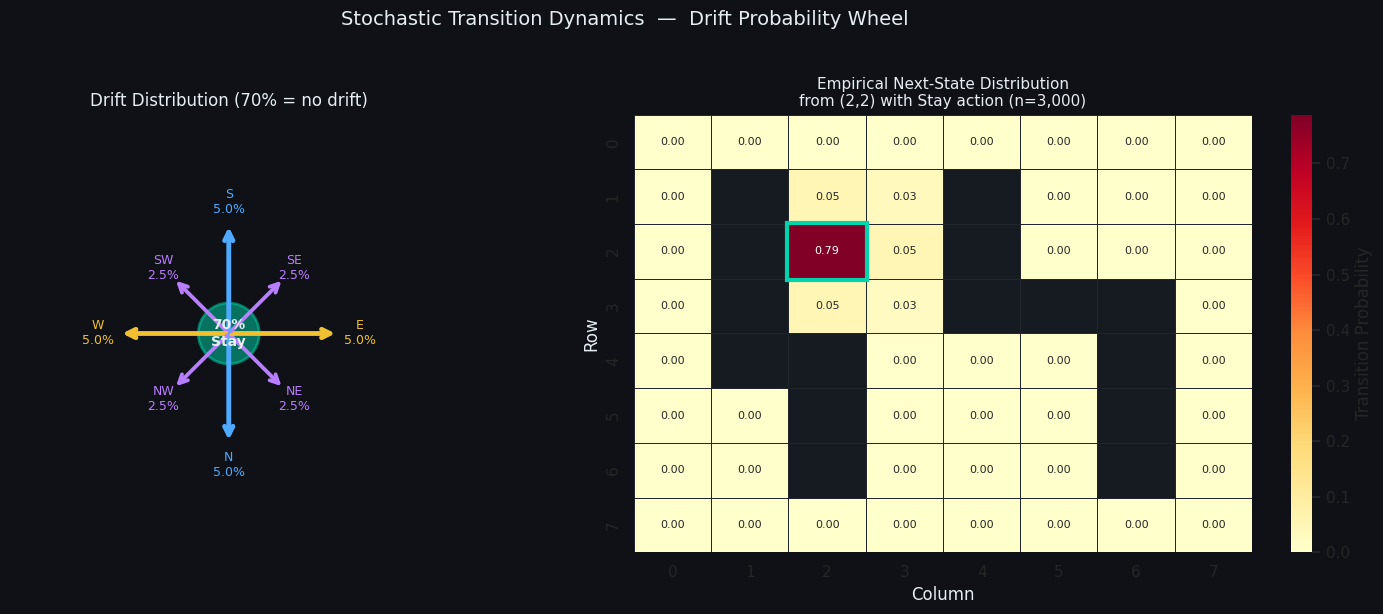

In [19]:
# ============================================================
# CELL 4: Stochastic Drift Diagram + Transition Dynamics
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0F1117')
fig.suptitle('Stochastic Transition Dynamics  —  Drift Probability Wheel',
             fontsize=14, color=WHITE, y=1.02)

# ─── Panel 1: Drift Probability Wheel ───────────────────────
ax = axes[0]
ax.set_facecolor('#0F1117')
ax.set_aspect('equal')

directions = [
    ('N',   (-0, -1),  0.050, '#4DAAFF'),
    ('NE',  (1,  -1),  0.025, '#B97EFF'),
    ('E',   (1,   0),  0.050, '#F0C030'),
    ('SE',  (1,   1),  0.025, '#B97EFF'),
    ('S',   (0,   1),  0.050, '#4DAAFF'),
    ('SW',  (-1,  1),  0.025, '#B97EFF'),
    ('W',   (-1,  0),  0.050, '#F0C030'),
    ('NW',  (-1, -1),  0.025, '#B97EFF'),
    ('Stay',(0,   0),  0.700, '#00D4AA'),
]
# Draw arrows proportional to probability
angle_map = {'N': 90, 'NE': 45, 'E': 0, 'SE': -45,
             'S': -90, 'SW': -135, 'W': 180, 'NW': 135}
for d_name, (dx, dy), prob, color in directions:
    if d_name == 'Stay':
        circ = Circle((0, 0), radius=0.2*prob**0.5,
                      facecolor=color, alpha=0.5, edgecolor=color, lw=2)
        ax.add_patch(circ)
        ax.text(0, 0, f'{prob:.0%}\nStay',
                ha='center', va='center', color=WHITE, fontsize=10, fontweight='bold')
    else:
        scale = prob * 12
        ax.annotate('', xy=(dx*scale, dy*scale), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color=color,
                            lw=2+prob*30, mutation_scale=15))
        ax.text(dx*scale*1.2, dy*scale*1.2, f'{d_name}\n{prob:.1%}',
                ha='center', va='center', color=color, fontsize=9)

ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Drift Distribution (70% = no drift)', color=WHITE, fontsize=12)
for spine in ax.spines.values(): spine.set_visible(False)

# ─── Panel 2: Empirical Transition Heatmap ─────────────────
# Sample from a few start states and see transition distribution
ax2 = axes[1]
test_state = (2, 2)   # example state
N_SAMPLES = 3000
trans_count = np.zeros((8, 8))

for _ in range(N_SAMPLES):
    env.reset_previous(list(test_state))
    _, _, _, _ = env.step(8)   # Stay action → drift only
    r, c = env.state
    if 0 <= r < 8 and 0 <= c < 8:
        trans_count[r, c] += 1

trans_prob = trans_count / N_SAMPLES
mask = np.zeros((8, 8), dtype=bool)
for r2, c2 in INV_STATES:
    mask[r2, c2] = True

sns.heatmap(trans_prob, ax=ax2,
            cmap='YlOrRd',
            annot=True, fmt='.2f',
            linewidths=0.5, linecolor='#21262D',
            mask=mask,
            cbar_kws={'label': 'Transition Probability'},
            annot_kws={'size': 8})

# Highlight origin
ax2.add_patch(Rectangle((test_state[1]-0.02, test_state[0]-0.02), 1.04, 1.04,
                          fill=False, edgecolor=TEAL, lw=3))
ax2.set_title(f'Empirical Next-State Distribution\nfrom ({test_state[0]},{test_state[1]}) with Stay action (n={N_SAMPLES:,})',
              color=WHITE, fontsize=11)
ax2.set_xlabel('Column', color=WHITE); ax2.set_ylabel('Row', color=WHITE)

fig.tight_layout()
plt.savefig('02_dynamics.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

In [20]:
# ============================================================
# CELL 5: Tabular Softmax Policy
# ============================================================
class TabularSoftmaxPolicy:
    """
    Direct parameterization: π(a|s) = exp(θ_{s,a}) / Σ_a' exp(θ_{s,a'})
    Parameters: θ ∈ R^{|S| × |A|}
    """
    def __init__(self, n_states=N_STATES, n_actions=N_ACTIONS, init_std=0.01):
        self.n_states  = n_states
        self.n_actions = n_actions
        self.theta = np.random.randn(n_states, n_actions) * init_std

    # ── Core computations ──────────────────────────────────
    def softmax(self, logits):
        e = np.exp(logits - logits.max())   # numerical stability
        return e / e.sum()

    def probs(self, state_idx):
        """π(·|s) — probability vector over actions"""
        return self.softmax(self.theta[state_idx])

    def sample_action(self, state_idx):
        p = self.probs(state_idx)
        return np.random.choice(self.n_actions, p=p)

    def log_prob(self, state_idx, action):
        p = self.probs(state_idx)
        return np.log(p[action] + 1e-12)

    def score_function(self, state_idx, action):
        """∇_θ log π(a|s) — score function / likelihood ratio"""
        p = self.probs(state_idx)
        grad = np.zeros_like(self.theta)
        grad[state_idx, action]  += 1.0
        grad[state_idx, :]       -= p
        return grad

    def kl_divergence(self, other):
        """KL(π_old ∥ π_new) averaged over valid states"""
        kl_total = 0.0
        for s in VALID_STATES:
            p_old = self.probs(s)
            p_new = other.probs(s)
            kl_total += np.sum(p_old * (np.log(p_old + 1e-12) - np.log(p_new + 1e-12)))
        return kl_total / len(VALID_STATES)

    def entropy(self, state_idx=None):
        """Policy entropy (avg or for specific state)"""
        if state_idx is not None:
            p = self.probs(state_idx)
            return -np.sum(p * np.log(p + 1e-12))
        return np.mean([self.entropy(s) for s in VALID_STATES])

    def copy(self):
        new = TabularSoftmaxPolicy(self.n_states, self.n_actions)
        new.theta = self.theta.copy()
        return new

print('✅ TabularSoftmaxPolicy class defined')
# Quick sanity check
pi = TabularSoftmaxPolicy()
for s in [0, 10, 36]:
    p = pi.probs(s)
    assert abs(p.sum() - 1.0) < 1e-9, 'Probabilities must sum to 1'
print('   Softmax sanity check passed: Σπ(a|s)=1 for all sampled states ✓')

✅ TabularSoftmaxPolicy class defined
   Softmax sanity check passed: Σπ(a|s)=1 for all sampled states ✓


In [21]:
# ============================================================
# CELL 6: Rollout & Q/V/Advantage Estimation
# ============================================================
def collect_episode(env, policy, max_steps=200, gamma=0.95):
    """
    Collect one episode: (states, actions, costs, log_probs).
    Returns: trajectory dict + total return.
    """
    state = env.reset()
    states, actions, costs, log_probs = [], [], [], []

    for t in range(max_steps):
        r, c = state
        s_idx = state_to_idx(r, c)
        a = policy.sample_action(s_idx)
        lp = policy.log_prob(s_idx, a)

        next_state, cost, done, _ = env.step(a)

        states.append(s_idx)
        actions.append(a)
        costs.append(cost)
        log_probs.append(lp)

        state = next_state
        if done:
            break

    # ── Discounted returns G_t = Σ_{k≥t} γ^{k-t} c_k ──────
    T = len(costs)
    returns = np.zeros(T)
    G = 0.0
    for t in reversed(range(T)):
        G = costs[t] + gamma * G
        returns[t] = G

    return {
        'states':    np.array(states),
        'actions':   np.array(actions),
        'costs':     np.array(costs),
        'returns':   returns,
        'log_probs': np.array(log_probs),
        'T':         T,
        'total_cost': np.sum(costs),
    }

def estimate_advantage(traj, baseline=None):
    """
    Advantage = G_t - baseline(s_t)
    baseline: callable(state_idx) -> float, or None (use mean return)
    """
    G = traj['returns']
    if baseline is None:
        b = np.mean(G)
        A = G - b
    else:
        b = np.array([baseline(s) for s in traj['states']])
        A = G - b
    return A

# Quick test
pi_test = TabularSoftmaxPolicy()
traj = collect_episode(env, pi_test, max_steps=200, gamma=0.95)
print(f'✅ Rollout OK | steps={traj["T"]} | total_cost={traj["total_cost"]:.2f}')

✅ Rollout OK | steps=46 | total_cost=23050.67


In [22]:
# ============================================================
# CELL 7: Policy Gradient (REINFORCE) Algorithm
# ============================================================
def policy_gradient_update(policy, traj, lr, gamma=0.95, use_baseline=True):
    """
    PG update: θ ← θ - α · Σ_t A_t · ∇ log π(a_t|s_t)
    Note: We MINIMIZE cost, so we subtract (not add) the gradient.
    """
    A = estimate_advantage(traj)
    grad = np.zeros_like(policy.theta)

    for t in range(traj['T']):
        s, a = traj['states'][t], traj['actions'][t]
        score = policy.score_function(s, a)
        grad += A[t] * score

    # gradient ascent on reward ≡ descent on cost
    policy.theta -= lr * grad / traj['T']
    return policy, grad

def train_pg(lr=0.01, n_episodes=500, gamma=0.95,
             max_steps=200, seed=42, verbose=False):
    """
    Full PG training run. Returns history dict.
    """
    np.random.seed(seed)
    policy = TabularSoftmaxPolicy()
    env_local = GridWorldEnv.__new__(GridWorldEnv)
    GridWorldEnv.__init__(env_local)

    history = {
        'episode_costs': [],
        'episode_steps': [],
        'entropy':       [],
        'grad_norms':    [],
        'kl_from_init':  [],
    }
    pi_init = policy.copy()

    for ep in range(n_episodes):
        traj = collect_episode(env_local, policy, max_steps, gamma)
        policy, grad = policy_gradient_update(policy, traj, lr, gamma)

        history['episode_costs'].append(traj['total_cost'])
        history['episode_steps'].append(traj['T'])
        history['entropy'].append(policy.entropy())
        history['grad_norms'].append(np.linalg.norm(grad))
        history['kl_from_init'].append(pi_init.kl_divergence(policy))

        if verbose and ep % 100 == 0:
            print(f'  ep {ep:4d} | cost={traj["total_cost"]:7.1f} | '
                  f'steps={traj["T"]:3d} | entropy={history["entropy"][-1]:.3f}')

    history['final_policy'] = policy
    return history

print('✅ PG algorithm defined')

✅ PG algorithm defined


In [23]:
# ============================================================
# CELL 8: Natural Policy Gradient (NPG) Algorithm
# ============================================================
def compute_fisher_matrix(policy, traj, eps=1e-4):
    """
    F(θ) = E[∇log π · ∇log π^T]
    Computed from observed trajectory data.
    """
    flat_dim = policy.theta.size
    F = np.zeros((flat_dim, flat_dim))

    for t in range(traj['T']):
        s, a = traj['states'][t], traj['actions'][t]
        score = policy.score_function(s, a).flatten()
        F += np.outer(score, score)

    F /= traj['T']
    F += eps * np.eye(flat_dim)   # regularization (F is PSD, may be singular)
    return F

def npg_step(policy, traj, delta=0.01, gamma=0.95, eps=1e-4):
    """
    NPG update:
      1. Compute policy gradient g = ∇J
      2. Compute Fisher F
      3. Natural gradient: ĝ = F^{-1} g
      4. Step size: λ = sqrt( ĝ^T F ĝ / (2δ) )  → ensures KL ≤ δ
      5. θ ← θ + (1/λ) · ĝ   [gradient ascent on reward / descent on cost]
    """
    A = estimate_advantage(traj)
    flat_dim = policy.theta.size
    grad = np.zeros(flat_dim)

    for t in range(traj['T']):
        s, a = traj['states'][t], traj['actions'][t]
        score = policy.score_function(s, a).flatten()
        grad += A[t] * score

    grad /= traj['T']

    # Fisher matrix
    F = compute_fisher_matrix(policy, traj, eps=eps)

    # Natural gradient: F^{-1} g
    try:
        F_inv_g = np.linalg.solve(F, grad)
    except np.linalg.LinAlgError:
        F_inv_g = grad   # fallback

    # Adaptive step size from KL budget δ
    quad = F_inv_g @ (F @ F_inv_g)
    if quad > 1e-10:
        lam = np.sqrt(quad / (2 * delta))
    else:
        lam = 1.0
    step = F_inv_g / (lam + 1e-8)

    policy.theta -= step.reshape(policy.theta.shape)

    return policy, grad, np.linalg.norm(step), np.linalg.cond(F)

def train_npg(delta=0.01, n_episodes=500, gamma=0.95,
              max_steps=200, seed=42, eps=1e-4, verbose=False):
    np.random.seed(seed)
    policy = TabularSoftmaxPolicy()
    env_local = GridWorldEnv.__new__(GridWorldEnv)
    GridWorldEnv.__init__(env_local)

    history = {
        'episode_costs': [],
        'episode_steps': [],
        'entropy':       [],
        'step_norms':    [],
        'kl_from_init':  [],
        'fisher_cond':   [],
    }
    pi_init = policy.copy()

    for ep in range(n_episodes):
        traj = collect_episode(env_local, policy, max_steps, gamma)
        policy, grad, step_norm, cond = npg_step(policy, traj, delta, gamma, eps)

        history['episode_costs'].append(traj['total_cost'])
        history['episode_steps'].append(traj['T'])
        history['entropy'].append(policy.entropy())
        history['step_norms'].append(step_norm)
        history['kl_from_init'].append(pi_init.kl_divergence(policy))
        history['fisher_cond'].append(cond)

        if verbose and ep % 100 == 0:
            print(f'  ep {ep:4d} | cost={traj["total_cost"]:7.1f} | '
                  f'steps={traj["T"]:3d} | δ={delta} | cond(F)={cond:.1e}')

    history['final_policy'] = policy
    return history

print('✅ NPG algorithm defined')

✅ NPG algorithm defined


In [24]:
# ============================================================
# CELL 9: Run All Experiments (PG + NPG with ablations)
# ============================================================
print('🚀 Running experiments... (this may take a minute)\n')

N_EPS    = 400
MAX_STEP = 150
GAMMA    = 0.95
N_SEEDS  = 5
SEEDS    = [42, 7, 13, 99, 2024]

# ─── PG: various learning rates ───────────────────────────
PG_LRS = [0.001, 0.005, 0.01, 0.05, 0.1]
pg_results = {}
for lr in PG_LRS:
    runs = []
    for seed in SEEDS:
        h = train_pg(lr=lr, n_episodes=N_EPS, gamma=GAMMA,
                     max_steps=MAX_STEP, seed=seed)
        runs.append(h)
    pg_results[lr] = runs
    costs = [np.mean(r['episode_costs'][-50:]) for r in runs]
    print(f'  PG lr={lr:.3f} | avg final cost: {np.mean(costs):.1f} ± {np.std(costs):.1f}')

print()

# ─── NPG: various delta values ─────────────────────────────
NPG_DELTAS = [0.001, 0.005, 0.01, 0.05, 0.1]
npg_results = {}
for delta in NPG_DELTAS:
    runs = []
    for seed in SEEDS:
        h = train_npg(delta=delta, n_episodes=N_EPS, gamma=GAMMA,
                      max_steps=MAX_STEP, seed=seed)
        runs.append(h)
    npg_results[delta] = runs
    costs = [np.mean(r['episode_costs'][-50:]) for r in runs]
    print(f'  NPG δ={delta:.3f} | avg final cost: {np.mean(costs):.1f} ± {np.std(costs):.1f}')

print('\n✅ All experiments complete!')

🚀 Running experiments... (this may take a minute)

GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
  PG lr=0.001 | avg final cost: 5602.4 ± 858.3
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
  PG lr=0.005 | avg final cost: 641.2 ± 140.5
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
  PG lr=0.010 | avg final cost: 282.5 ± 54.3
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
  PG lr=0.050 | avg final cost: 1662.5 ± 1662.6
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
Grid

In [25]:
# ============================================================
# CELL 10: Utility: Smoothing & Aggregation Helpers
# ============================================================
def smooth(x, w=20):
    """Exponential moving average for nicer plots."""
    s = np.zeros_like(x, dtype=float)
    alpha = 2 / (w + 1)
    s[0] = x[0]
    for i in range(1, len(x)):
        s[i] = alpha * x[i] + (1 - alpha) * s[i-1]
    return s

def aggregate_runs(runs, key):
    """Return (mean, std) arrays across seeds."""
    data = np.array([r[key] for r in runs])
    return data.mean(0), data.std(0)

def rolling_stats(x, w=30):
    """Rolling mean & std."""
    mean = pd.Series(x).rolling(w, min_periods=1).mean().values
    std  = pd.Series(x).rolling(w, min_periods=1).std().fillna(0).values
    return mean, std

print('✅ Utility functions ready')

✅ Utility functions ready


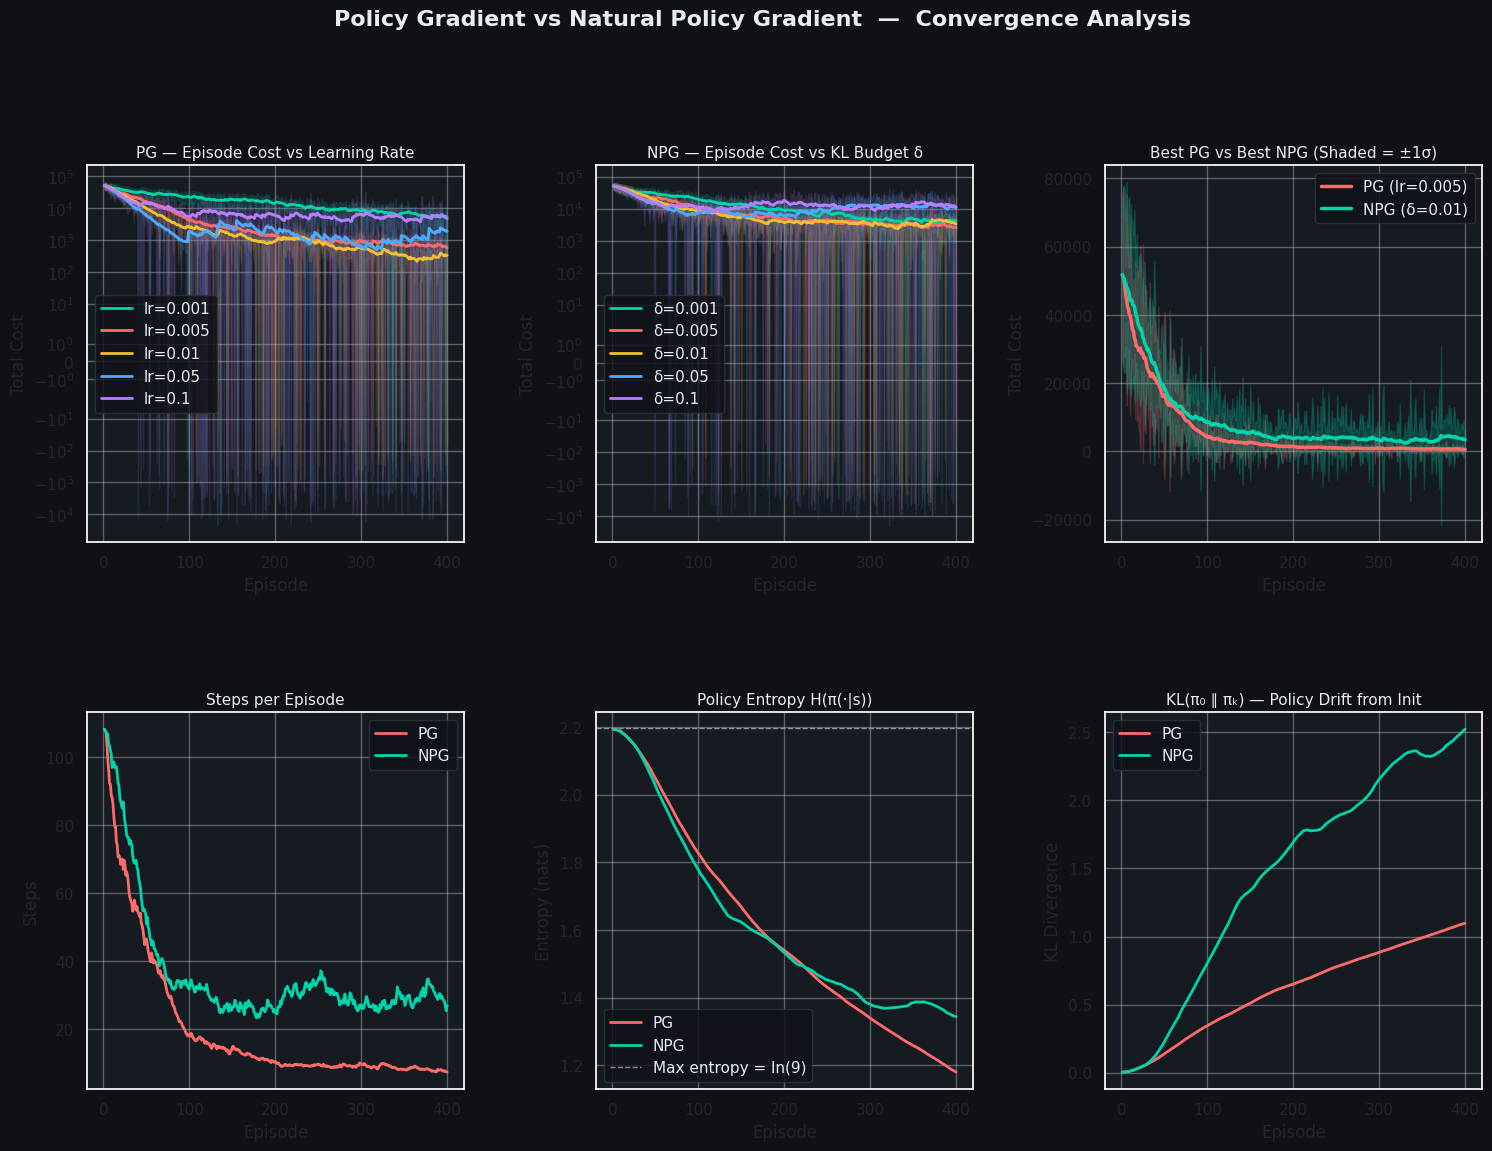

In [26]:
# ============================================================
# CELL 11: Learning Curve Comparison — PG vs NPG
# ============================================================
fig = plt.figure(figsize=(18, 12), facecolor='#0F1117')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

fig.suptitle('Policy Gradient vs Natural Policy Gradient  —  Convergence Analysis',
             fontsize=16, color=WHITE, y=1.01, fontweight='bold')

episodes = np.arange(1, N_EPS + 1)

# ─── Top row: Cost curves ──────────────────────────────────
# PG
ax_pg = fig.add_subplot(gs[0, 0])
ax_pg.set_facecolor('#161B22')
ax_pg.set_title('PG — Episode Cost vs Learning Rate', color=WHITE, fontsize=11)

for i, lr in enumerate(PG_LRS):
    mu, sd = aggregate_runs(pg_results[lr], 'episode_costs')
    mu_s = smooth(mu, 30)
    c = PALETTE[i]
    ax_pg.plot(episodes, mu_s, color=c, lw=2, label=f'lr={lr}')
    ax_pg.fill_between(episodes, mu_s - sd/2, mu_s + sd/2,
                        color=c, alpha=0.12)
ax_pg.set_xlabel('Episode'); ax_pg.set_ylabel('Total Cost')
ax_pg.legend(facecolor='#0F1117', edgecolor='#30363D', labelcolor=WHITE)
ax_pg.grid(True, alpha=0.3)
ax_pg.set_yscale('symlog')

# NPG
ax_npg = fig.add_subplot(gs[0, 1])
ax_npg.set_facecolor('#161B22')
ax_npg.set_title('NPG — Episode Cost vs KL Budget δ', color=WHITE, fontsize=11)

for i, delta in enumerate(NPG_DELTAS):
    mu, sd = aggregate_runs(npg_results[delta], 'episode_costs')
    mu_s = smooth(mu, 30)
    c = PALETTE[i]
    ax_npg.plot(episodes, mu_s, color=c, lw=2, label=f'δ={delta}')
    ax_npg.fill_between(episodes, mu_s - sd/2, mu_s + sd/2,
                         color=c, alpha=0.12)
ax_npg.set_xlabel('Episode'); ax_npg.set_ylabel('Total Cost')
ax_npg.legend(facecolor='#0F1117', edgecolor='#30363D', labelcolor=WHITE)
ax_npg.grid(True, alpha=0.3)
ax_npg.set_yscale('symlog')

# Overlay Best PG vs Best NPG
ax_cmp = fig.add_subplot(gs[0, 2])
ax_cmp.set_facecolor('#161B22')
ax_cmp.set_title('Best PG vs Best NPG (Shaded = ±1σ)', color=WHITE, fontsize=11)

# Best PG: lr=0.005 (typically stable)
best_pg_lr = 0.005
mu_pg, sd_pg = aggregate_runs(pg_results[best_pg_lr], 'episode_costs')
mu_pg_s = smooth(mu_pg, 30)
ax_cmp.plot(episodes, mu_pg_s, color=CORAL, lw=2.5, label=f'PG (lr={best_pg_lr})')
ax_cmp.fill_between(episodes, mu_pg_s - sd_pg, mu_pg_s + sd_pg,
                     color=CORAL, alpha=0.2)

# Best NPG: delta=0.01
best_npg_d = 0.01
mu_npg, sd_npg = aggregate_runs(npg_results[best_npg_d], 'episode_costs')
mu_npg_s = smooth(mu_npg, 30)
ax_cmp.plot(episodes, mu_npg_s, color=TEAL, lw=2.5, label=f'NPG (δ={best_npg_d})')
ax_cmp.fill_between(episodes, mu_npg_s - sd_npg, mu_npg_s + sd_npg,
                     color=TEAL, alpha=0.2)

ax_cmp.set_xlabel('Episode'); ax_cmp.set_ylabel('Total Cost')
ax_cmp.legend(facecolor='#0F1117', edgecolor='#30363D', labelcolor=WHITE)
ax_cmp.grid(True, alpha=0.3)

# ─── Bottom row: Steps, Entropy, KL ───────────────────────
ax_steps   = fig.add_subplot(gs[1, 0])
ax_entropy = fig.add_subplot(gs[1, 1])
ax_kl      = fig.add_subplot(gs[1, 2])

for ax in [ax_steps, ax_entropy, ax_kl]:
    ax.set_facecolor('#161B22')
    ax.grid(True, alpha=0.3)

# Steps to reach terminal
mu_pg_st, _ = aggregate_runs(pg_results[best_pg_lr], 'episode_steps')
mu_npg_st,_ = aggregate_runs(npg_results[best_npg_d], 'episode_steps')
ax_steps.plot(episodes, smooth(mu_pg_st,  30), color=CORAL, lw=2, label='PG')
ax_steps.plot(episodes, smooth(mu_npg_st, 30), color=TEAL,  lw=2, label='NPG')
ax_steps.set_title('Steps per Episode', color=WHITE, fontsize=11)
ax_steps.set_xlabel('Episode'); ax_steps.set_ylabel('Steps')
ax_steps.legend(facecolor='#0F1117', edgecolor='#30363D', labelcolor=WHITE)

# Policy entropy (measures exploration vs exploitation)
mu_pg_ent, _ = aggregate_runs(pg_results[best_pg_lr], 'entropy')
mu_npg_ent,_ = aggregate_runs(npg_results[best_npg_d], 'entropy')
ax_entropy.plot(episodes, smooth(mu_pg_ent,  30), color=CORAL, lw=2, label='PG')
ax_entropy.plot(episodes, smooth(mu_npg_ent, 30), color=TEAL,  lw=2, label='NPG')
ax_entropy.axhline(np.log(N_ACTIONS), color=GRAY, lw=1, ls='--',
                    label=f'Max entropy = ln({N_ACTIONS})')
ax_entropy.set_title('Policy Entropy H(π(·|s))', color=WHITE, fontsize=11)
ax_entropy.set_xlabel('Episode'); ax_entropy.set_ylabel('Entropy (nats)')
ax_entropy.legend(facecolor='#0F1117', edgecolor='#30363D', labelcolor=WHITE)

# KL from initial policy
mu_pg_kl, _ = aggregate_runs(pg_results[best_pg_lr], 'kl_from_init')
mu_npg_kl,_ = aggregate_runs(npg_results[best_npg_d], 'kl_from_init')
ax_kl.plot(episodes, smooth(mu_pg_kl,  30), color=CORAL, lw=2, label='PG')
ax_kl.plot(episodes, smooth(mu_npg_kl, 30), color=TEAL,  lw=2, label='NPG')
ax_kl.set_title('KL(π₀ ∥ πₖ) — Policy Drift from Init', color=WHITE, fontsize=11)
ax_kl.set_xlabel('Episode'); ax_kl.set_ylabel('KL Divergence')
ax_kl.legend(facecolor='#0F1117', edgecolor='#30363D', labelcolor=WHITE)

plt.savefig('03_convergence.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

Computing MC value estimates (PG policy)...
GridWorldEnv (Fox2016) Loaded...
Computing MC value estimates (NPG policy)...
GridWorldEnv (Fox2016) Loaded...


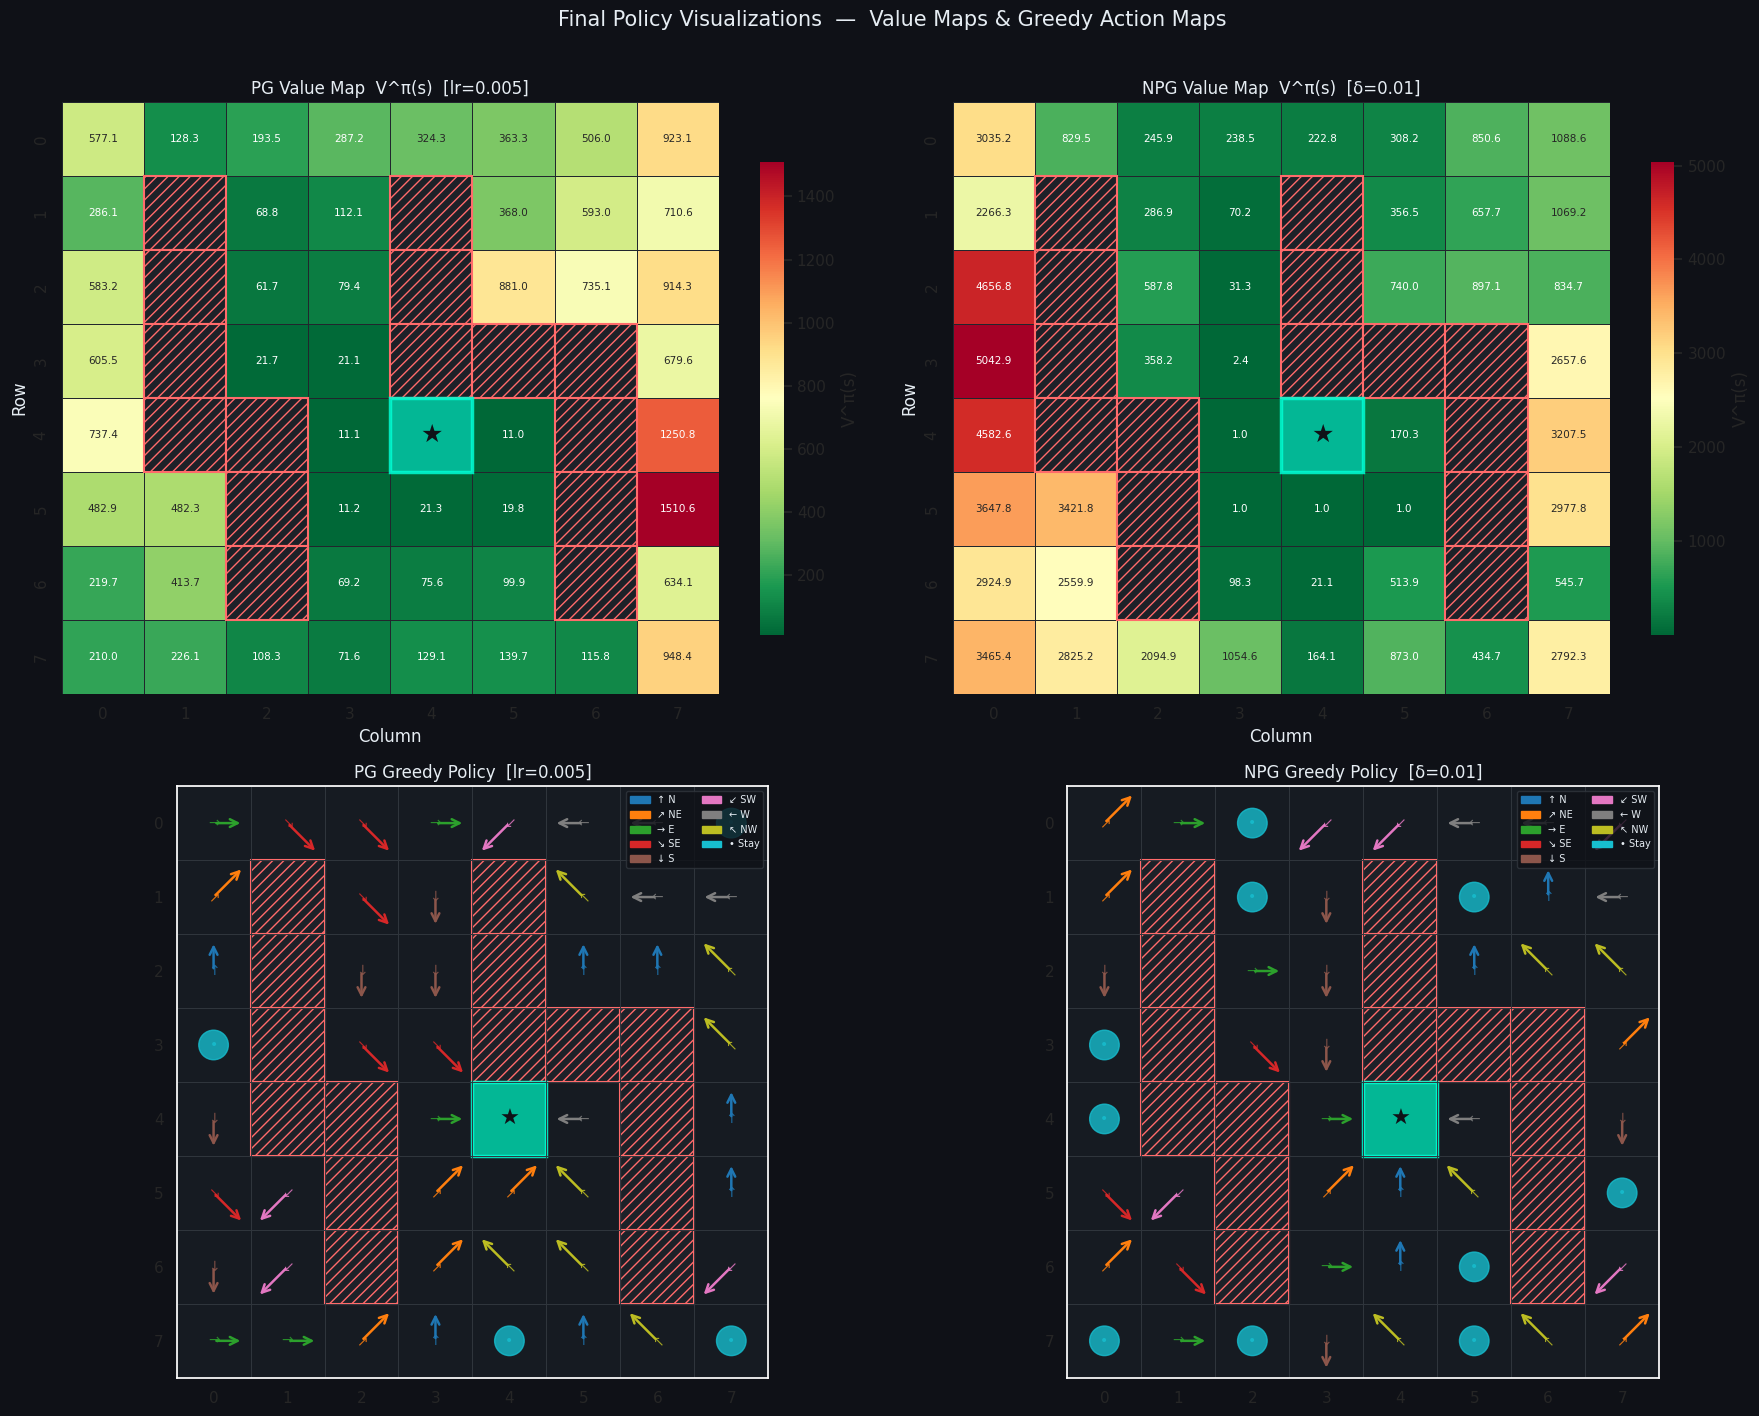

In [27]:
# ============================================================
# CELL 12: Final Policy Heatmaps — Greedy Action & Value Map
# ============================================================
def compute_value_map(policy, n_mc=200, max_steps=150, gamma=0.95):
    """Monte Carlo estimate of V^π(s) for each valid state."""
    val = np.full((8, 8), np.nan)
    env_v = GridWorldEnv.__new__(GridWorldEnv)
    GridWorldEnv.__init__(env_v)

    for idx in VALID_STATES:
        r0, c0 = idx_to_state(idx)
        returns = []
        for _ in range(n_mc):
            env_v.reset_previous([r0, c0])
            G = 0.0
            discount = 1.0
            for _ in range(max_steps):
                sr, sc = env_v.state
                si = state_to_idx(sr, sc)
                a  = policy.sample_action(si)
                _, cost, done, _ = env_v.step(a)
                G += discount * cost
                discount *= gamma
                if done: break
            returns.append(G)
        val[r0, c0] = np.mean(returns)
    return val

def get_greedy_action_map(policy):
    gmap = np.full((8, 8), -1, dtype=int)
    for idx in VALID_STATES:
        r, c = idx_to_state(idx)
        gmap[r, c] = np.argmax(policy.probs(idx))
    return gmap

# Get final policies
pg_final  = pg_results[best_pg_lr][0]['final_policy']
npg_final = npg_results[best_npg_d][0]['final_policy']

print('Computing MC value estimates (PG policy)...')
val_pg  = compute_value_map(pg_final,  n_mc=100)
print('Computing MC value estimates (NPG policy)...')
val_npg = compute_value_map(npg_final, n_mc=100)

act_pg  = get_greedy_action_map(pg_final)
act_npg = get_greedy_action_map(npg_final)

fig, axes = plt.subplots(2, 2, figsize=(18, 14), facecolor='#0F1117')
fig.suptitle('Final Policy Visualizations  —  Value Maps & Greedy Action Maps',
             fontsize=15, color=WHITE, y=1.01)

def plot_value_map(ax, val_mat, title, label='V^π(s)'):
    ax.set_facecolor('#161B22')
    mask = np.zeros((8,8), dtype=bool)
    for r2, c2 in INV_STATES: mask[r2,c2]=True
    mask[TERMINAL[0], TERMINAL[1]] = True

    sns.heatmap(val_mat, ax=ax, cmap='RdYlGn_r',
                annot=True, fmt='.1f', linewidths=0.4,
                linecolor='#21262D', mask=mask,
                cbar_kws={'label': label, 'shrink': 0.8},
                annot_kws={'size': 7.5})

    for r2, c2 in INV_STATES:
        rect = Rectangle((c2, r2), 1, 1, facecolor='#1C2128',
                          edgecolor='#FF6B6B', lw=1.5, hatch='///')
        ax.add_patch(rect)

    # Terminal
    tr, tc = TERMINAL
    rect = Rectangle((tc, tr), 1, 1, facecolor='#00D4AA',
                      edgecolor='#00FFD4', lw=2.5, alpha=0.85)
    ax.add_patch(rect)
    ax.text(tc+0.5, tr+0.5, '★', ha='center', va='center',
            fontsize=18, color='#0F1117')

    ax.set_title(title, color=WHITE, fontsize=12)
    ax.set_xlabel('Column', color=WHITE)
    ax.set_ylabel('Row', color=WHITE)

plot_value_map(axes[0,0], val_pg,  f'PG Value Map  V^π(s)  [lr={best_pg_lr}]')
plot_value_map(axes[0,1], val_npg, f'NPG Value Map  V^π(s)  [δ={best_npg_d}]')

def plot_action_map(ax, act_mat, title):
    ax.set_facecolor('#161B22')
    ax.set_xlim(-0.5, 7.5); ax.set_ylim(7.5, -0.5)
    ax.set_aspect('equal')

    for x in range(9): ax.axhline(x-0.5, color='#30363D', lw=0.7)
    for x in range(9): ax.axvline(x-0.5, color='#30363D', lw=0.7)

    cmap_act = plt.cm.get_cmap('tab10', N_ACTIONS)

    for idx in VALID_STATES:
        r, c = idx_to_state(idx)
        a = act_mat[r, c]
        if a < 0: continue
        dr, dc = ACTION_DELTAS[a]
        color = cmap_act(a)
        if a == 8:  # Stay
            circ = Circle((c, r), 0.2, color=color, alpha=0.8)
            ax.add_patch(circ)
        else:
            ax.annotate('', xy=(c + dc*0.4, r + dr*0.4),
                        xytext=(c, r),
                        arrowprops=dict(arrowstyle='->', color=color,
                                        lw=1.8, mutation_scale=14))
        ax.text(c, r, ACTION_SYMBOLS[a], ha='center', va='center',
                fontsize=10, color=color, alpha=0.85)

    # Blocked
    for r2, c2 in INV_STATES:
        rect = Rectangle((c2-0.5, r2-0.5), 1, 1, facecolor='#1C2128',
                          edgecolor='#FF6B6B', lw=1.5, hatch='///')
        ax.add_patch(rect)

    # Terminal
    tr, tc = TERMINAL
    rect = Rectangle((tc-0.5, tr-0.5), 1, 1, facecolor='#00D4AA',
                      edgecolor='#00FFD4', lw=2.5, alpha=0.85)
    ax.add_patch(rect)
    ax.text(tc, tr, '★', ha='center', va='center', fontsize=16, color='#0F1117')

    ax.set_title(title, color=WHITE, fontsize=12)
    ax.set_xticks(range(8)); ax.set_yticks(range(8))

    legend_patches2 = [mpatches.Patch(color=cmap_act(i),
                        label=f'{ACTION_SYMBOLS[i]} {ACTION_NAMES[i]}')
                       for i in range(N_ACTIONS)]
    ax.legend(handles=legend_patches2, loc='upper right',
              facecolor='#0F1117', edgecolor='#30363D',
              labelcolor=WHITE, fontsize=7, ncol=2)

plot_action_map(axes[1,0], act_pg,  f'PG Greedy Policy  [lr={best_pg_lr}]')
plot_action_map(axes[1,1], act_npg, f'NPG Greedy Policy  [δ={best_npg_d}]')

fig.tight_layout()
plt.savefig('04_policy_maps.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

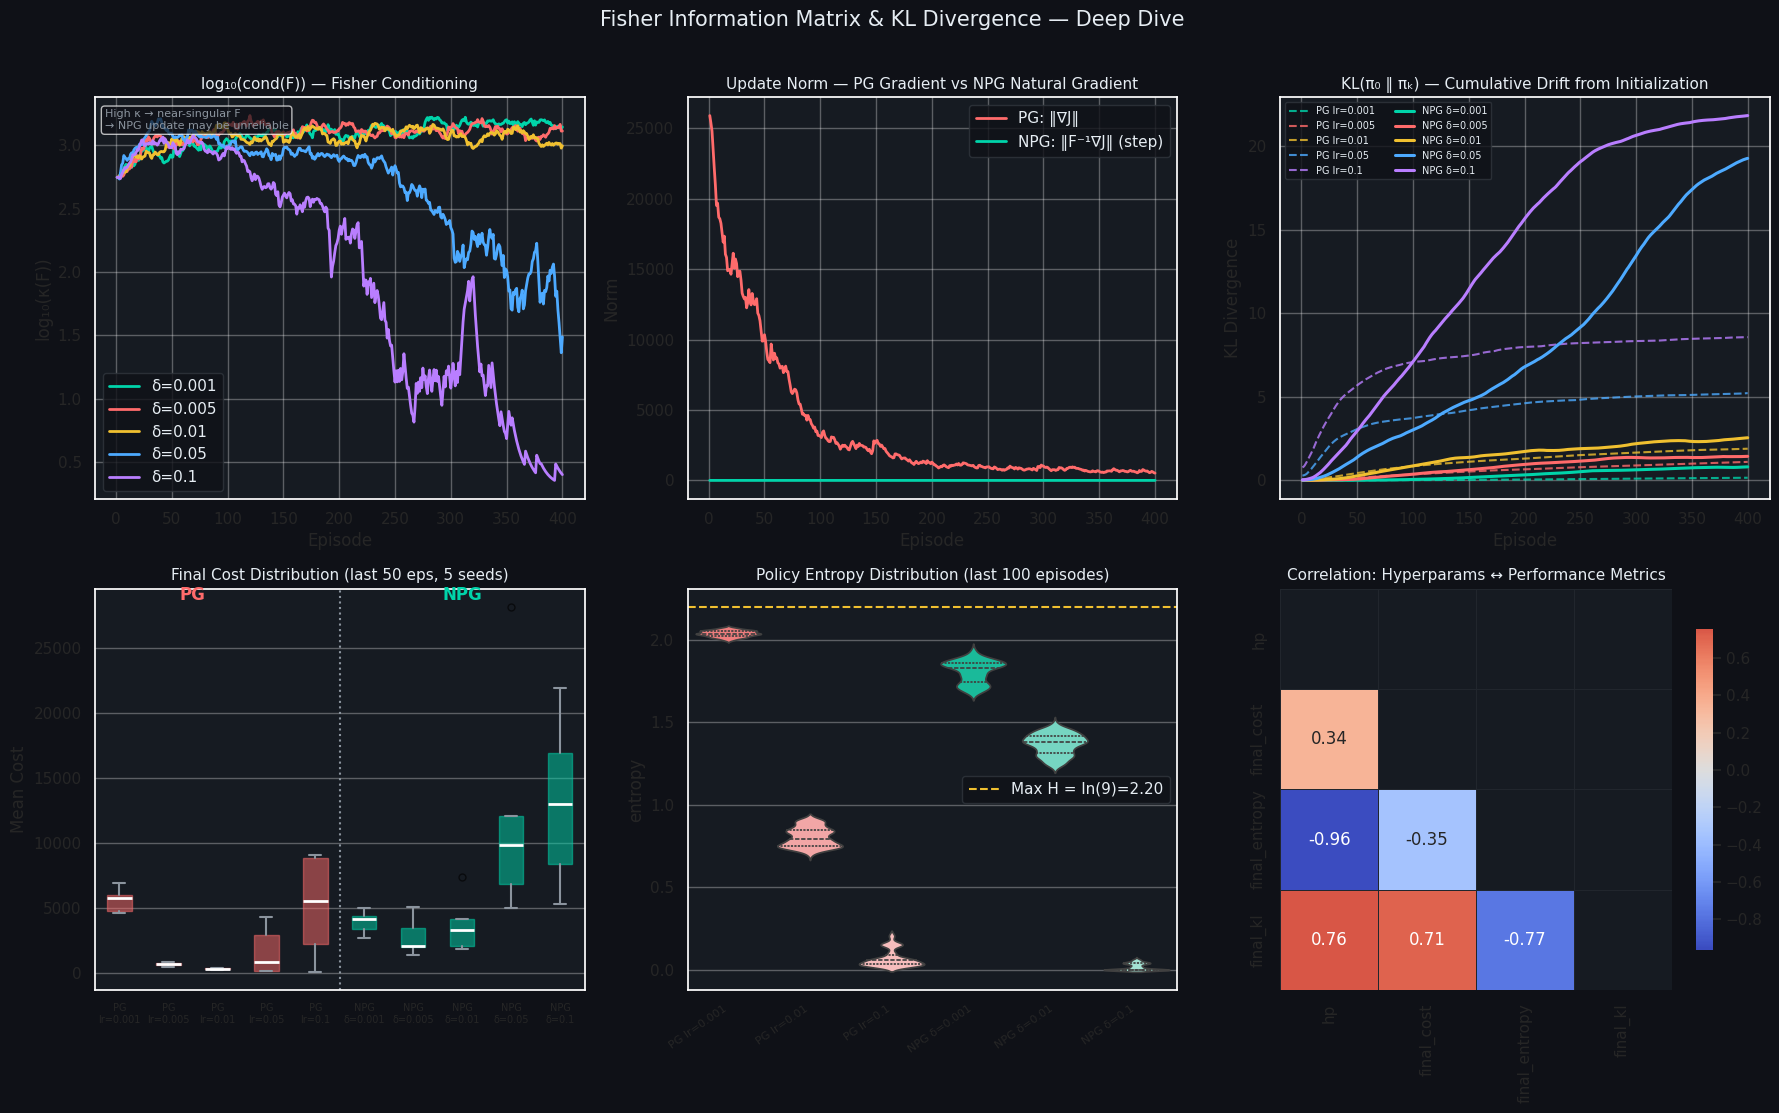

In [32]:
# ============================================================
# CELL 13: Fisher Information & KL Dynamics Analysis
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11), facecolor='#0F1117')
fig.suptitle('Fisher Information Matrix & KL Divergence — Deep Dive',
             fontsize=15, color=WHITE, y=1.01)

# ─── (0,0): Fisher condition number across training ─────────
ax = axes[0, 0]; ax.set_facecolor('#161B22')
for i, delta in enumerate(NPG_DELTAS):
    mu, sd = aggregate_runs(npg_results[delta], 'fisher_cond')
    mu_s = smooth(np.log10(mu + 1), 20)
    ax.plot(episodes, mu_s, color=PALETTE[i], lw=2, label=f'δ={delta}')
ax.set_title('log₁₀(cond(F)) — Fisher Conditioning', color=WHITE, fontsize=11)
ax.set_xlabel('Episode'); ax.set_ylabel('log₁₀(κ(F))')
ax.legend(facecolor='#0F1117', edgecolor='#30363D', labelcolor=WHITE)
ax.grid(True, alpha=0.3)
ax.text(0.02, 0.97, 'High κ → near-singular F\n→ NPG update may be unreliable',
        transform=ax.transAxes, color=GRAY, fontsize=8,
        va='top', bbox=dict(boxstyle='round', facecolor='#0F1117', alpha=0.7))

# ─── (0,1): Step norm comparison PG vs NPG ─────────────────
ax = axes[0, 1]; ax.set_facecolor('#161B22')
mu_pg_gn,  _ = aggregate_runs(pg_results[best_pg_lr],  'grad_norms')
mu_npg_sn, _ = aggregate_runs(npg_results[best_npg_d], 'step_norms')
ax.plot(episodes, smooth(mu_pg_gn,  20), color=CORAL, lw=2, label='PG: ‖∇J‖')
ax.plot(episodes, smooth(mu_npg_sn, 20), color=TEAL,  lw=2, label='NPG: ‖F⁻¹∇J‖ (step)')
ax.set_title('Update Norm — PG Gradient vs NPG Natural Gradient', color=WHITE, fontsize=11)
ax.set_xlabel('Episode'); ax.set_ylabel('Norm')
ax.legend(facecolor='#0F1117', edgecolor='#30363D', labelcolor=WHITE)
ax.grid(True, alpha=0.3)

# ─── (0,2): KL divergence per episode for PG vs NPG ─────────
ax = axes[0, 2]; ax.set_facecolor('#161B22')
for i, lr in enumerate(PG_LRS):
    mu, _ = aggregate_runs(pg_results[lr], 'kl_from_init')
    ax.plot(episodes, smooth(mu, 20), color=PALETTE[i],
            lw=1.5, ls='--', alpha=0.8, label=f'PG lr={lr}')
for i, delta in enumerate(NPG_DELTAS):
    mu, _ = aggregate_runs(npg_results[delta], 'kl_from_init')
    ax.plot(episodes, smooth(mu, 20), color=PALETTE[i],
            lw=2.2, label=f'NPG δ={delta}')
ax.set_title('KL(π₀ ‖ πₖ) — Cumulative Drift from Initialization', color=WHITE, fontsize=11)
ax.set_xlabel('Episode'); ax.set_ylabel('KL Divergence')
ax.legend(facecolor='#0F1117', edgecolor='#30363D', labelcolor=WHITE,
          fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# ─── (1,0): Final cost boxplot ──────────────────────────────
ax = axes[1, 0]; ax.set_facecolor('#161B22')
box_data = []
box_labels = []
box_colors = []

for lr in PG_LRS:
    finals = [np.mean(r['episode_costs'][-50:]) for r in pg_results[lr]]
    box_data.append(finals)
    box_labels.append(f'PG\nlr={lr}')
    box_colors.append(CORAL)

for delta in NPG_DELTAS:
    finals = [np.mean(r['episode_costs'][-50:]) for r in npg_results[delta]]
    box_data.append(finals)
    box_labels.append(f'NPG\nδ={delta}')
    box_colors.append(TEAL)

bp = ax.boxplot(box_data, patch_artist=True, medianprops=dict(color='white', lw=2))
for patch, color in zip(bp['boxes'], box_colors):
    patch.set(facecolor=color, alpha=0.5, edgecolor=color)
for whisker in bp['whiskers']: whisker.set(color=GRAY, lw=1.5)
for cap in bp['caps']: cap.set(color=GRAY, lw=1.5)
for flier in bp['fliers']:
    flier.set(marker='o', color=GOLD, markersize=5, alpha=0.6)

ax.set_xticks(range(1, len(box_labels)+1))
ax.set_xticklabels(box_labels, fontsize=7)
ax.set_title('Final Cost Distribution (last 50 eps, 5 seeds)', color=WHITE, fontsize=11)
ax.set_ylabel('Mean Cost')
ax.grid(True, axis='y', alpha=0.3)
ax.axvline(len(PG_LRS) + 0.5, color=GRAY, ls=':', lw=1.5)
ax.text(2.5, ax.get_ylim()[1]*0.97, 'PG', ha='center', color=CORAL, fontweight='bold')
ax.text(len(PG_LRS)+3, ax.get_ylim()[1]*0.97, 'NPG', ha='center', color=TEAL, fontweight='bold')

# ─── (1,1): Violin plot for entropy distribution ───────────
ax = axes[1, 1]; ax.set_facecolor('#161B22')
ent_df_rows = []
for lr in [0.001, 0.01, 0.1]:
    for run in pg_results[lr]:
        for ep_ent in run['entropy'][-100:]:
            ent_df_rows.append({'algo': f'PG lr={lr}', 'entropy': ep_ent})
for delta in [0.001, 0.01, 0.1]:
    for run in npg_results[delta]:
        for ep_ent in run['entropy'][-100:]:
            ent_df_rows.append({'algo': f'NPG δ={delta}', 'entropy': ep_ent})
ent_df = pd.DataFrame(ent_df_rows)

sns.violinplot(data=ent_df, x='algo', y='entropy', ax=ax,
               palette={'PG lr=0.001': CORAL, 'PG lr=0.01': '#FF9999',
                         'PG lr=0.1': '#FFB3B3',
                         'NPG δ=0.001': TEAL, 'NPG δ=0.01': '#66E5CC',
                         'NPG δ=0.1': '#99EDD9'},
               inner='quartile')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)
ax.set_title('Policy Entropy Distribution (last 100 episodes)', color=WHITE, fontsize=11)
ax.set_xlabel('')
ax.axhline(np.log(N_ACTIONS), color=GOLD, lw=1.5, ls='--',
           label=f'Max H = ln({N_ACTIONS})={np.log(N_ACTIONS):.2f}')
ax.legend(facecolor='#0F1117', edgecolor='#30363D', labelcolor=WHITE)
ax.grid(True, axis='y', alpha=0.3)

# ─── (1,2): Correlation heatmap: hyperparams vs performance ─
ax = axes[1, 2]; ax.set_facecolor('#161B22')
perf_data = []
for lr in PG_LRS:
    for seed_i, run in enumerate(pg_results[lr]):
        perf_data.append({
            'algo': 0,  # PG=0
            'hp': np.log10(lr),
            'final_cost': np.mean(run['episode_costs'][-50:]),
            'final_entropy': run['entropy'][-1],
            'final_kl': run['kl_from_init'][-1],
        })
for delta in NPG_DELTAS:
    for seed_i, run in enumerate(npg_results[delta]):
        perf_data.append({
            'algo': 1,  # NPG=1
            'hp': np.log10(delta),
            'final_cost': np.mean(run['episode_costs'][-50:]),
            'final_entropy': run['entropy'][-1],
            'final_kl': run['kl_from_init'][-1],
        })
perf_df = pd.DataFrame(perf_data)
corr = perf_df.drop(columns=['algo']).corr()

mask_c = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', mask=mask_c,
            linewidths=0.5, linecolor='#21262D',
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation: Hyperparams ↔ Performance Metrics', color=WHITE, fontsize=11)

fig.tight_layout()
plt.savefig('05_fisher_kl_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...


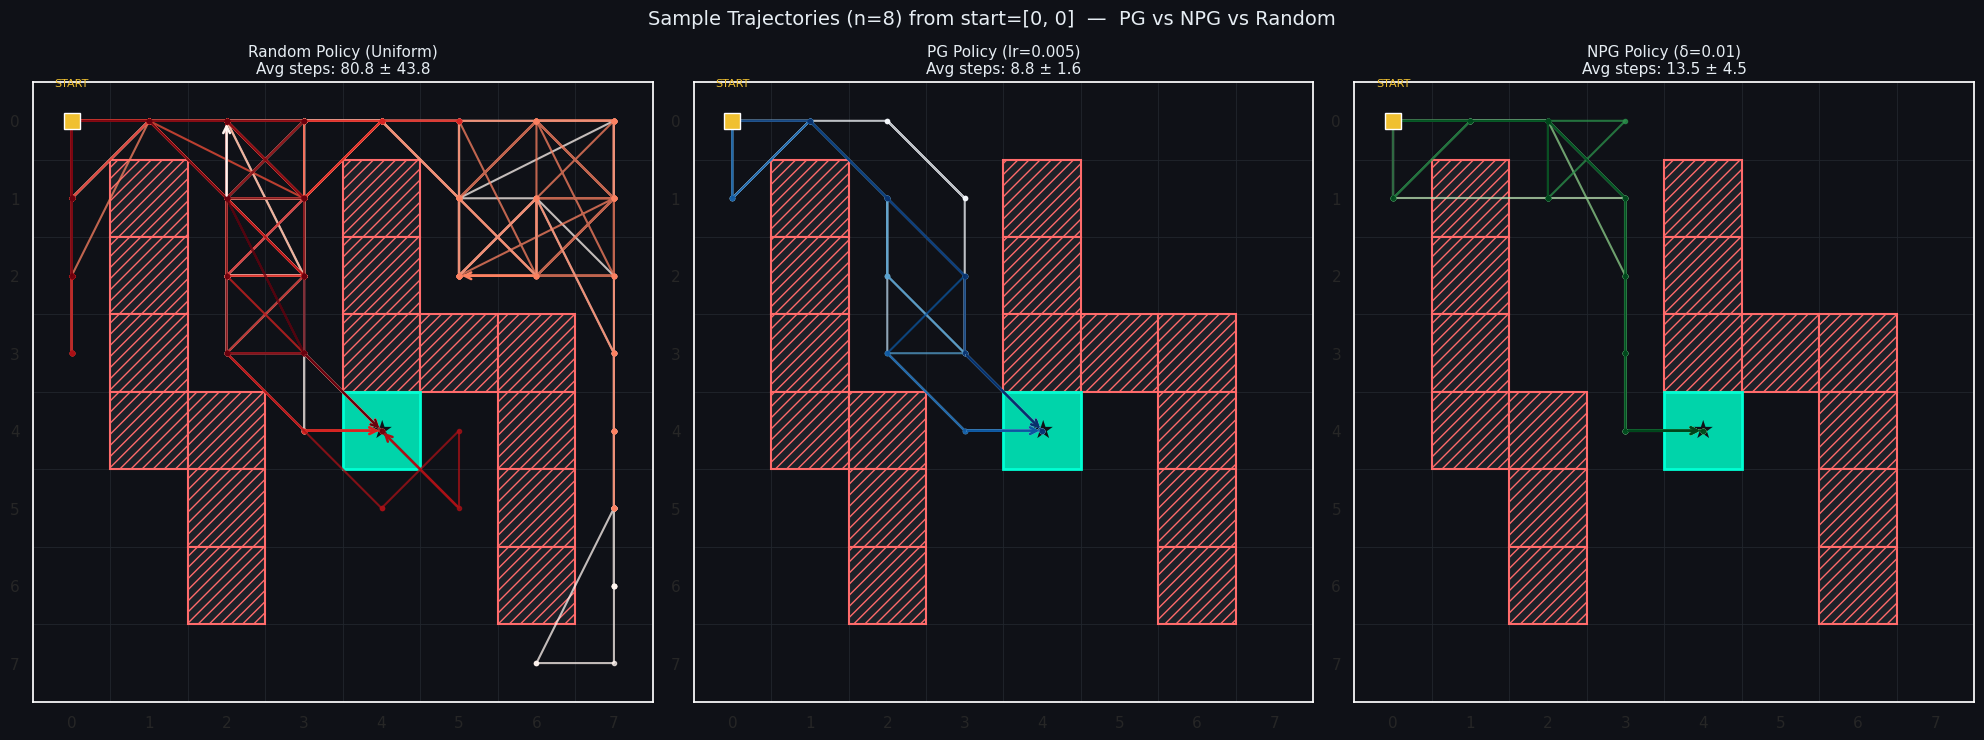

In [33]:
# ============================================================
# CELL 14: Sample Trajectory Visualization — PG vs NPG
# ============================================================
def sample_trajectory_path(policy, n_steps=150, start=None):
    """Return list of (row, col) visited."""
    env_t = GridWorldEnv.__new__(GridWorldEnv)
    GridWorldEnv.__init__(env_t)
    if start:
        env_t.reset_previous(start)
    else:
        env_t.reset()

    path = [tuple(env_t.state)]
    for _ in range(n_steps):
        r, c = env_t.state
        si = state_to_idx(r, c)
        a  = policy.sample_action(si)
        _, _, done, _ = env_t.step(a)
        path.append(tuple(env_t.state))
        if done: break
    return path

N_TRAJ = 8
START  = [0, 0]   # top-left corner

fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor='#0F1117')
fig.suptitle(f'Sample Trajectories (n={N_TRAJ}) from start={START}  —  PG vs NPG vs Random',
             fontsize=14, color=WHITE, y=1.02)

def plot_trajectories(ax, policy, title, n_traj=N_TRAJ, cmap_name='plasma'):
    ax.set_facecolor('#0F1117')
    ax.set_xlim(-0.5, 7.5); ax.set_ylim(7.5, -0.5)
    ax.set_aspect('equal')

    for x in range(9):
        ax.axhline(x-0.5, color='#21262D', lw=0.6)
        ax.axvline(x-0.5, color='#21262D', lw=0.6)

    # Blocked cells
    for r2, c2 in INV_STATES:
        rect = Rectangle((c2-0.5, r2-0.5), 1, 1,
                          facecolor='#1C2128', edgecolor='#FF6B6B',
                          lw=1.5, hatch='///', zorder=2)
        ax.add_patch(rect)

    # Terminal
    tr, tc = TERMINAL
    rect = Rectangle((tc-0.5, tr-0.5), 1, 1,
                      facecolor='#00D4AA', edgecolor='#00FFD4', lw=2, zorder=2)
    ax.add_patch(rect)
    ax.text(tc, tr, '★', ha='center', va='center', fontsize=18,
            color='#0F1117', zorder=3)

    cmap_t = plt.cm.get_cmap(cmap_name, n_traj)
    lengths = []

    for i in range(n_traj):
        path = sample_trajectory_path(policy, n_steps=150, start=START)
        lengths.append(len(path))
        rows = [p[0] for p in path]
        cols = [p[1] for p in path]
        color = cmap_t(i)
        ax.plot(cols, rows, '-o', color=color, lw=1.5, ms=3, alpha=0.75, zorder=4)
        # Arrow at end
        if len(rows) > 1:
            ax.annotate('', xy=(cols[-1], rows[-1]),
                        xytext=(cols[-2], rows[-2]),
                        arrowprops=dict(arrowstyle='->', color=color,
                                        lw=1.8, mutation_scale=12),
                        zorder=5)

    # Start marker
    ax.plot(START[1], START[0], 's', color=GOLD, ms=12,
            markeredgecolor='white', zorder=6, label='Start')
    ax.text(START[1], START[0]-0.45, 'START', ha='center', color=GOLD, fontsize=8)

    ax.set_title(f'{title}\nAvg steps: {np.mean(lengths):.1f} ± {np.std(lengths):.1f}',
                 color=WHITE, fontsize=11)
    ax.set_xticks(range(8)); ax.set_yticks(range(8))

# Random policy
random_policy = TabularSoftmaxPolicy()
random_policy.theta = np.zeros_like(random_policy.theta)  # uniform

plot_trajectories(axes[0], random_policy, 'Random Policy (Uniform)', cmap_name='Reds')
plot_trajectories(axes[1], pg_final,      f'PG Policy (lr={best_pg_lr})', cmap_name='Blues')
plot_trajectories(axes[2], npg_final,     f'NPG Policy (δ={best_npg_d})', cmap_name='Greens')

fig.tight_layout()
plt.savefig('06_trajectories.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

Running γ ablation...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
  γ=0.7  done
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
  γ=0.8  done
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loa

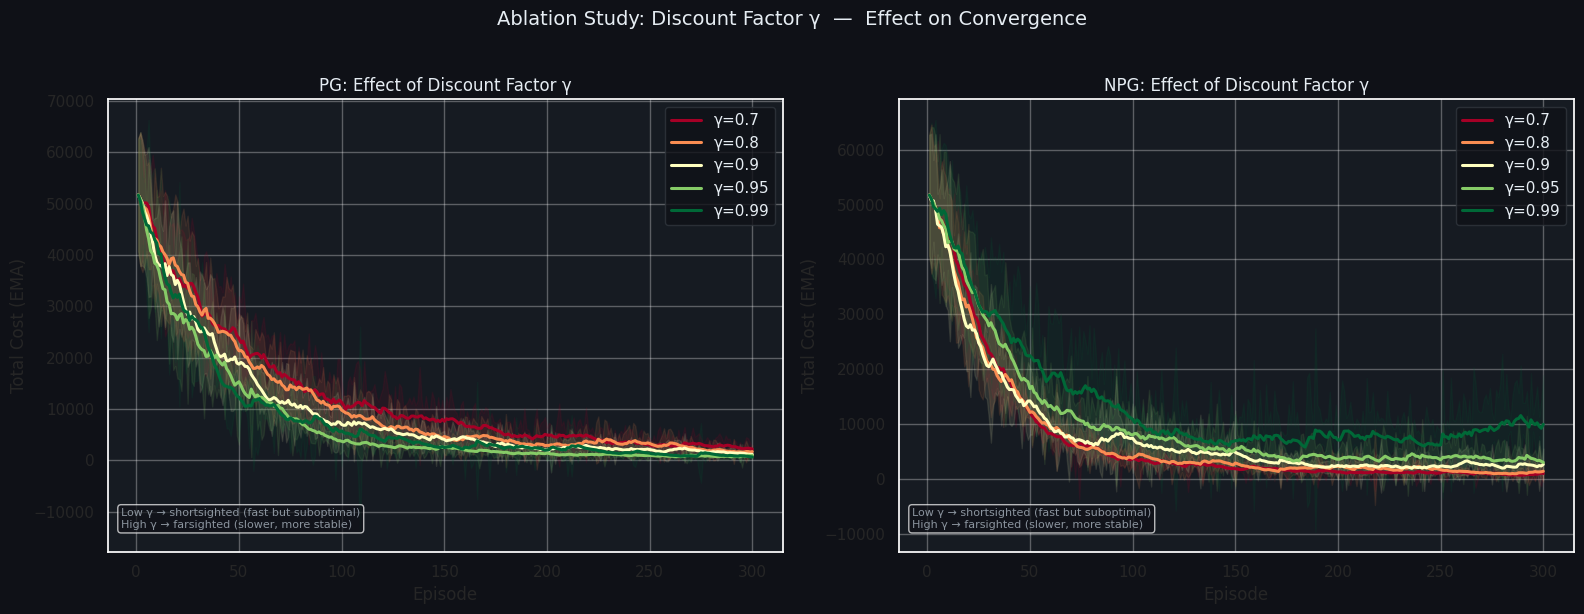

In [31]:
# ============================================================
# CELL 15: Ablation Study — Discount Factor γ
# ============================================================
print('Running γ ablation...')
GAMMAS = [0.70, 0.80, 0.90, 0.95, 0.99]
gamma_pg_results  = {}
gamma_npg_results = {}

for g in GAMMAS:
    pg_runs, npg_runs = [], []
    for seed in SEEDS:
        pg_runs.append(train_pg(lr=best_pg_lr, n_episodes=300,
                                gamma=g, max_steps=MAX_STEP, seed=seed))
        npg_runs.append(train_npg(delta=best_npg_d, n_episodes=300,
                                  gamma=g, max_steps=MAX_STEP, seed=seed))
    gamma_pg_results[g]  = pg_runs
    gamma_npg_results[g] = npg_runs
    print(f'  γ={g}  done')

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0F1117')
fig.suptitle('Ablation Study: Discount Factor γ  —  Effect on Convergence',
             fontsize=14, color=WHITE, y=1.02)

eps_g = np.arange(1, 301)
cmap_g = plt.cm.get_cmap('RdYlGn', len(GAMMAS))

for ax, results, algo in [(axes[0], gamma_pg_results, 'PG'),
                           (axes[1], gamma_npg_results, 'NPG')]:
    ax.set_facecolor('#161B22')
    for i, g in enumerate(GAMMAS):
        mu, sd = aggregate_runs(results[g], 'episode_costs')
        mu_s = smooth(mu, 25)
        c = cmap_g(i)
        ax.plot(eps_g, mu_s, color=c, lw=2.2, label=f'γ={g}')
        ax.fill_between(eps_g, mu_s - sd*0.5, mu_s + sd*0.5, color=c, alpha=0.1)
    ax.set_title(f'{algo}: Effect of Discount Factor γ', color=WHITE, fontsize=12)
    ax.set_xlabel('Episode'); ax.set_ylabel('Total Cost (EMA)')
    ax.legend(facecolor='#0F1117', edgecolor='#30363D', labelcolor=WHITE)
    ax.grid(True, alpha=0.3)

    # Annotation about γ role
    ax.text(0.02, 0.05,
        'Low γ → shortsighted (fast but suboptimal)\nHigh γ → farsighted (slower, more stable)',
        transform=ax.transAxes, color=GRAY, fontsize=8, va='bottom',
        bbox=dict(boxstyle='round', facecolor='#0F1117', alpha=0.7))

fig.tight_layout()
plt.savefig('07_gamma_ablation.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

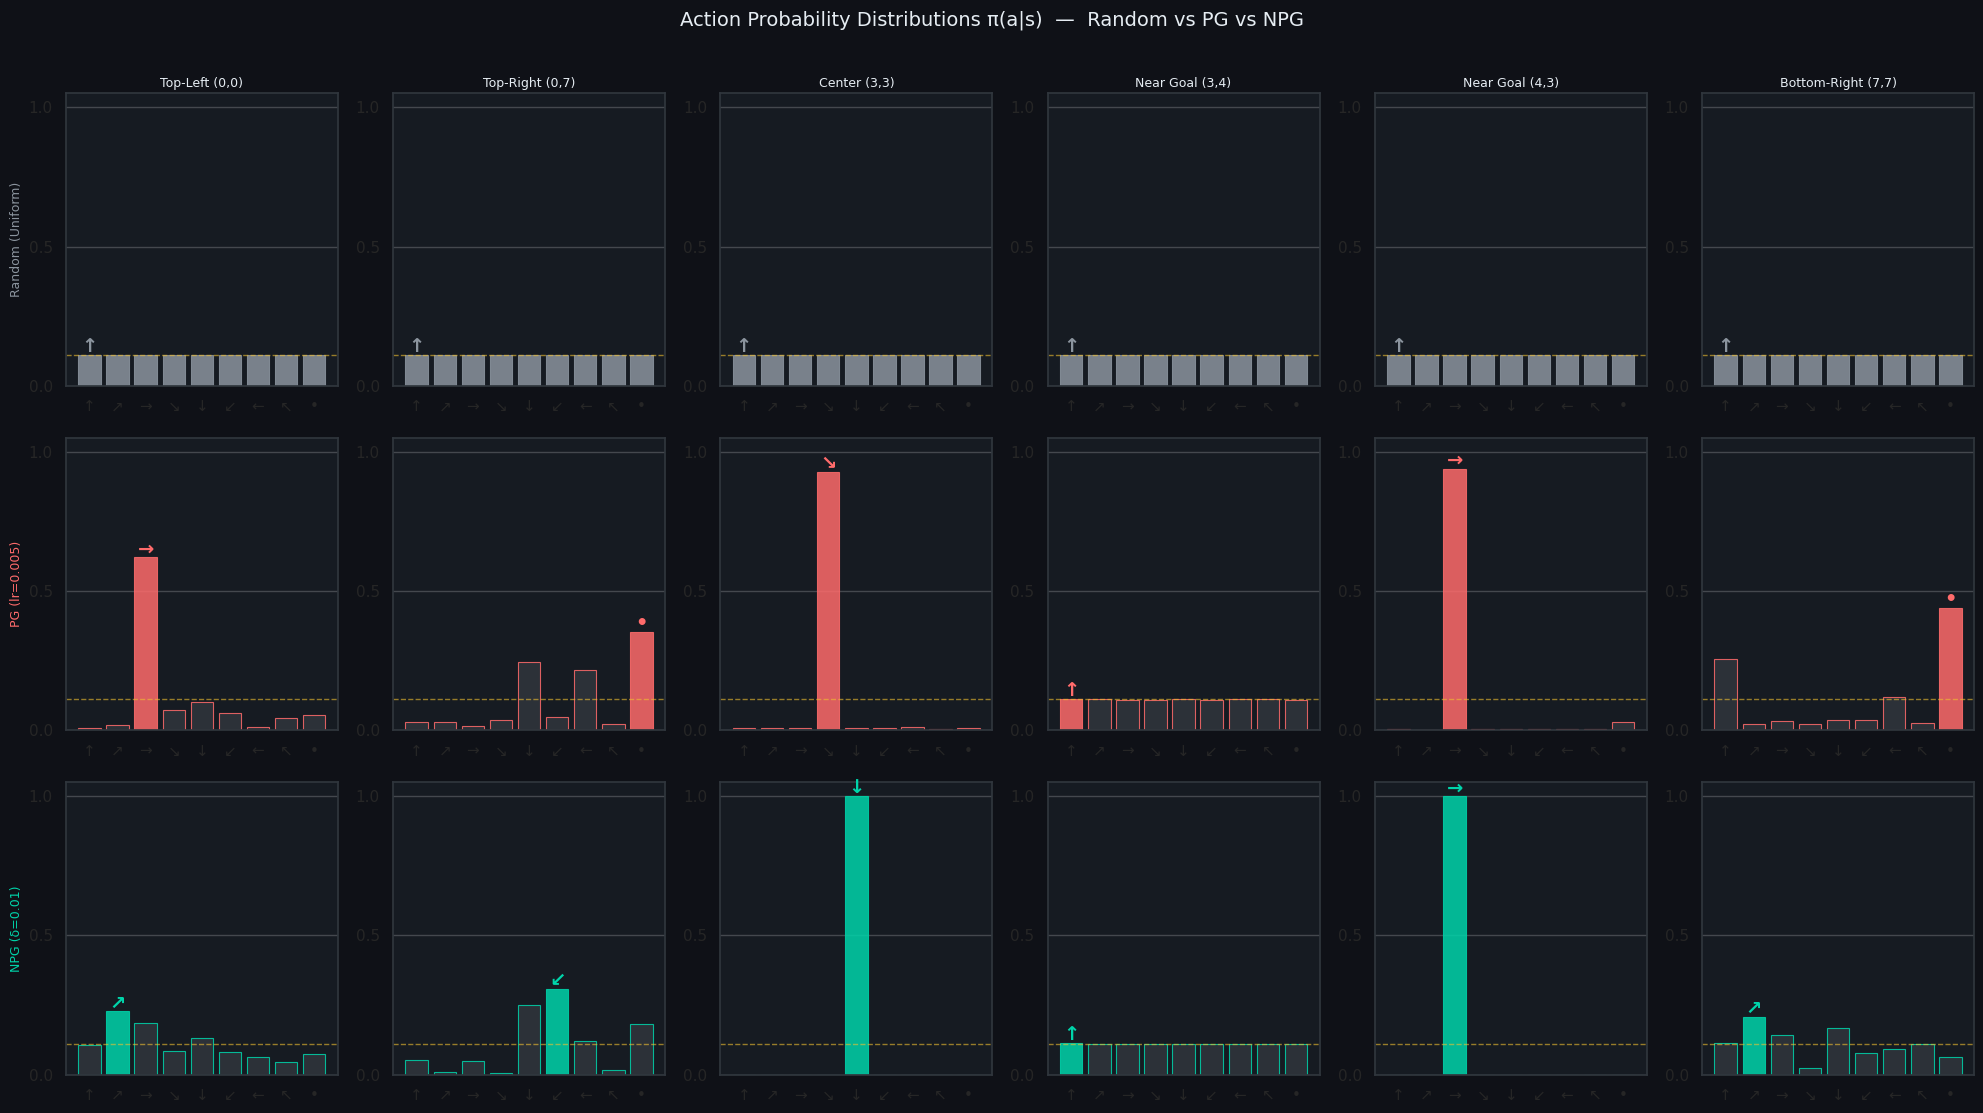

In [34]:
# ============================================================
# CELL 16: Action Probability Distributions for Key States
# ============================================================
# Choose illustrative states: corners, near-goal, far-from-goal
KEY_STATES = {
    'Top-Left (0,0)': state_to_idx(0, 0),
    'Top-Right (0,7)': state_to_idx(0, 7),
    'Center (3,3)': state_to_idx(3, 3),
    'Near Goal (3,4)': state_to_idx(3, 4),
    'Near Goal (4,3)': state_to_idx(4, 3),
    'Bottom-Right (7,7)': state_to_idx(7, 7),
}

n_states_shown = len(KEY_STATES)
fig, axes = plt.subplots(3, n_states_shown, figsize=(20, 11), facecolor='#0F1117')
fig.suptitle('Action Probability Distributions π(a|s)  —  Random vs PG vs NPG',
             fontsize=14, color=WHITE, y=1.01)

policies = [
    (random_policy, 'Random (Uniform)', '#8B949E'),
    (pg_final,  f'PG (lr={best_pg_lr})', CORAL),
    (npg_final, f'NPG (δ={best_npg_d})', TEAL),
]

for row_i, (pol, pol_name, pol_color) in enumerate(policies):
    for col_i, (state_name, s_idx) in enumerate(KEY_STATES.items()):
        ax = axes[row_i, col_i]
        ax.set_facecolor('#161B22')

        probs = pol.probs(s_idx)
        bars = ax.bar(range(N_ACTIONS), probs,
                      color=[pol_color if p == probs.max() else '#30363D' for p in probs],
                      edgecolor=pol_color, linewidth=0.8, alpha=0.85)

        # Highlight max action
        best_a = np.argmax(probs)
        ax.text(best_a, probs[best_a] + 0.01, ACTION_SYMBOLS[best_a],
                ha='center', color=pol_color, fontsize=14, fontweight='bold')

        ax.set_xticks(range(N_ACTIONS))
        ax.set_xticklabels(ACTION_SYMBOLS, fontsize=11)
        ax.set_ylim(0, 1.05)
        ax.set_yticks([0, 0.5, 1.0])
        ax.axhline(1/N_ACTIONS, color=GOLD, lw=1, ls='--', alpha=0.6)

        if row_i == 0:
            ax.set_title(state_name, color=WHITE, fontsize=9, pad=5)
        if col_i == 0:
            ax.set_ylabel(pol_name, color=pol_color, fontsize=9)
        ax.grid(True, axis='y', alpha=0.2)
        for spine in ax.spines.values():
            spine.set_edgecolor('#30363D')

fig.tight_layout()
plt.savefig('08_action_probs.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

Computing state visitation...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...


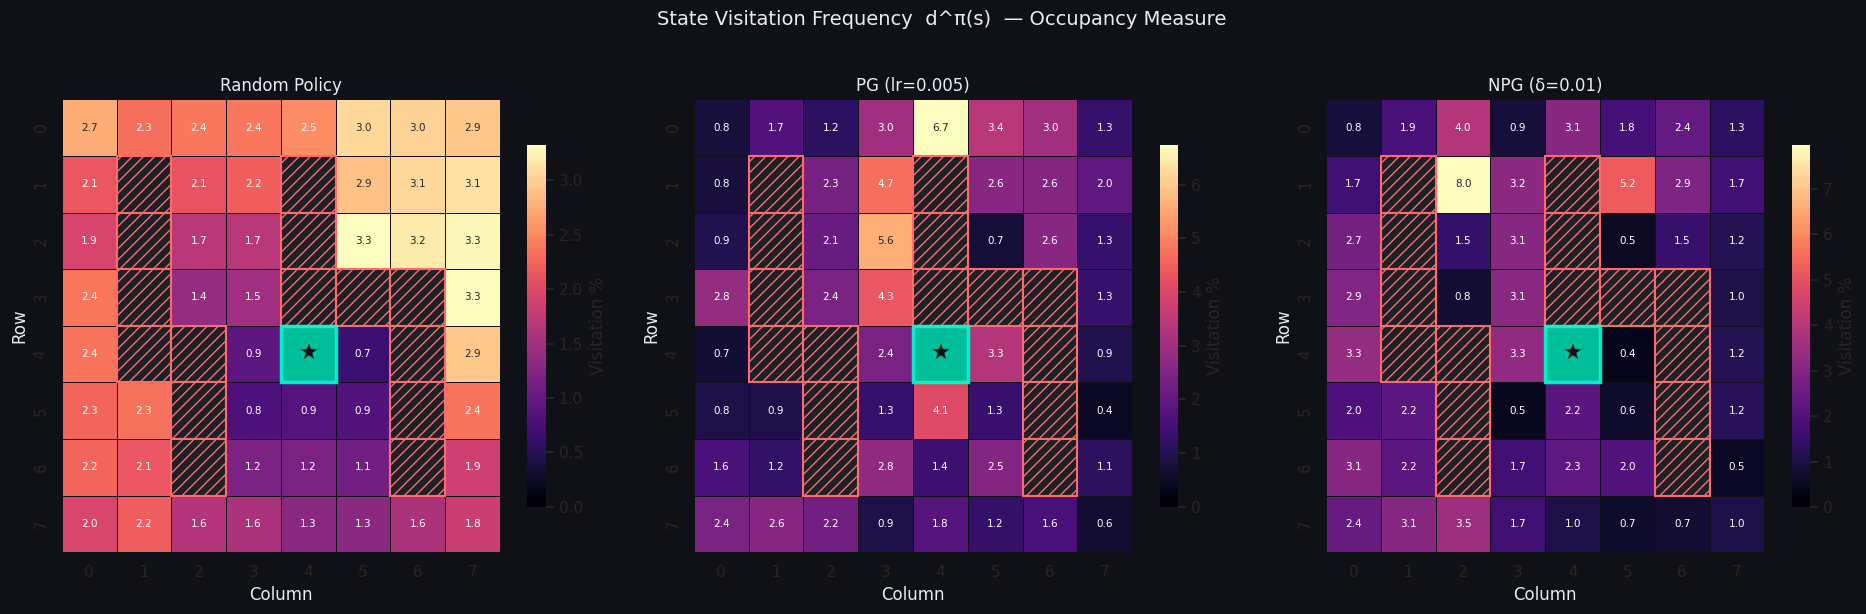

In [35]:
# ============================================================
# CELL 17: State Visitation Frequency — PG vs NPG vs Random
# ============================================================
def compute_state_visitation(policy, n_episodes=200, max_steps=150):
    visit = np.zeros((8, 8))
    env_sv = GridWorldEnv.__new__(GridWorldEnv)
    GridWorldEnv.__init__(env_sv)

    for _ in range(n_episodes):
        state = env_sv.reset()
        for _ in range(max_steps):
            r, c = state
            visit[r, c] += 1
            si = state_to_idx(r, c)
            a  = policy.sample_action(si)
            state, _, done, _ = env_sv.step(a)
            if done: break

    visit /= (visit.sum() + 1e-9)
    return visit

print('Computing state visitation...')
visit_random = compute_state_visitation(random_policy, n_episodes=300)
visit_pg     = compute_state_visitation(pg_final,      n_episodes=300)
visit_npg    = compute_state_visitation(npg_final,     n_episodes=300)

fig, axes = plt.subplots(1, 3, figsize=(19, 6), facecolor='#0F1117')
fig.suptitle('State Visitation Frequency  d^π(s)  — Occupancy Measure',
             fontsize=14, color=WHITE, y=1.02)

for ax, visit, title in [
    (axes[0], visit_random, 'Random Policy'),
    (axes[1], visit_pg,     f'PG (lr={best_pg_lr})'),
    (axes[2], visit_npg,    f'NPG (δ={best_npg_d})'),
]:
    mask_sv = np.zeros((8,8), dtype=bool)
    for r2, c2 in INV_STATES: mask_sv[r2,c2] = True

    sns.heatmap(visit * 100, ax=ax,
                cmap='magma',
                annot=True, fmt='.1f',
                linewidths=0.4, linecolor='#0F1117',
                mask=mask_sv,
                cbar_kws={'label': 'Visitation %', 'shrink': 0.8},
                annot_kws={'size': 7.5},
                vmin=0)

    for r2, c2 in INV_STATES:
        rect = Rectangle((c2, r2), 1, 1, facecolor='#1C2128',
                          edgecolor='#FF6B6B', lw=1.5, hatch='///', zorder=3)
        ax.add_patch(rect)

    tr, tc = TERMINAL
    rect = Rectangle((tc, tr), 1, 1, facecolor='#00D4AA',
                      edgecolor='#00FFD4', lw=2.5, alpha=0.9, zorder=3)
    ax.add_patch(rect)
    ax.text(tc+0.5, tr+0.5, '★', ha='center', va='center', fontsize=16,
            color='#0F1117', zorder=4)

    ax.set_title(title, color=WHITE, fontsize=12)
    ax.set_xlabel('Column', color=WHITE)
    ax.set_ylabel('Row', color=WHITE)

fig.tight_layout()
plt.savefig('09_visitation.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

In [36]:
# ============================================================
# CELL 18: Comprehensive Performance Summary Table
# ============================================================
rows = []

for lr in PG_LRS:
    all_final = [np.mean(r['episode_costs'][-50:]) for r in pg_results[lr]]
    all_ent   = [r['entropy'][-1]                  for r in pg_results[lr]]
    all_kl    = [r['kl_from_init'][-1]             for r in pg_results[lr]]
    all_steps = [np.mean(r['episode_steps'][-50:]) for r in pg_results[lr]]
    rows.append({
        'Algorithm': f'PG (lr={lr})',
        'Final Cost μ':   f'{np.mean(all_final):.1f}',
        'Final Cost σ':   f'{np.std(all_final):.1f}',
        'Avg Steps':      f'{np.mean(all_steps):.1f}',
        'Entropy':        f'{np.mean(all_ent):.3f}',
        'KL from π₀':     f'{np.mean(all_kl):.4f}',
        'Fisher Cond':    'N/A',
    })

for delta in NPG_DELTAS:
    all_final = [np.mean(r['episode_costs'][-50:]) for r in npg_results[delta]]
    all_ent   = [r['entropy'][-1]                  for r in npg_results[delta]]
    all_kl    = [r['kl_from_init'][-1]             for r in npg_results[delta]]
    all_steps = [np.mean(r['episode_steps'][-50:]) for r in npg_results[delta]]
    all_cond  = [np.mean(r['fisher_cond'][-50:])   for r in npg_results[delta]]
    rows.append({
        'Algorithm': f'NPG (δ={delta})',
        'Final Cost μ':   f'{np.mean(all_final):.1f}',
        'Final Cost σ':   f'{np.std(all_final):.1f}',
        'Avg Steps':      f'{np.mean(all_steps):.1f}',
        'Entropy':        f'{np.mean(all_ent):.3f}',
        'KL from π₀':     f'{np.mean(all_kl):.4f}',
        'Fisher Cond':    f'{np.mean(all_cond):.2e}',
    })

summary_df = pd.DataFrame(rows)
print('=' * 95)
print('COMPREHENSIVE PERFORMANCE SUMMARY')
print('=' * 95)
print(summary_df.to_string(index=False))
print('=' * 95)
print()
print('Columns:')
print('  Final Cost μ/σ : Mean ± std of total episode cost (last 50 eps, 5 seeds)')
print('  Avg Steps      : Mean steps to reach terminal or timeout')
print('  Entropy        : Avg policy entropy H(π(·|s)) — higher = more exploration')
print('  KL from π₀     : KL divergence from initial (uniform) policy')
print('  Fisher Cond    : Condition number κ(F) — stability of NPG update')

COMPREHENSIVE PERFORMANCE SUMMARY
    Algorithm Final Cost μ Final Cost σ Avg Steps Entropy KL from π₀ Fisher Cond
PG (lr=0.001)       5602.4        858.3      22.5   2.006     0.1645         N/A
PG (lr=0.005)        641.2        140.5       7.8   1.160     1.1225         N/A
 PG (lr=0.01)        282.5         54.3      12.1   0.756     1.9160         N/A
 PG (lr=0.05)       1662.5       1662.6      43.6   0.195     5.2544         N/A
  PG (lr=0.1)       5133.0       3560.4      62.3   0.060     8.5773         N/A
NPG (δ=0.001)       3885.6        804.6      15.3   1.762     0.8342    1.55e+03
NPG (δ=0.005)       2776.8       1309.0      24.2   1.532     1.4657    1.37e+03
 NPG (δ=0.01)       3722.7       2002.9      29.1   1.330     2.6082    1.19e+03
 NPG (δ=0.05)      12343.7       8267.2      84.6   0.093    19.4431    2.14e+02
  NPG (δ=0.1)      13094.7       5925.2      74.7   0.005    21.9039    7.54e+00

Columns:
  Final Cost μ/σ : Mean ± std of total episode cost (last 50 eps,

Estimating J(π) at training checkpoints...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...
GridWorldEnv (Fox2016) Loaded...


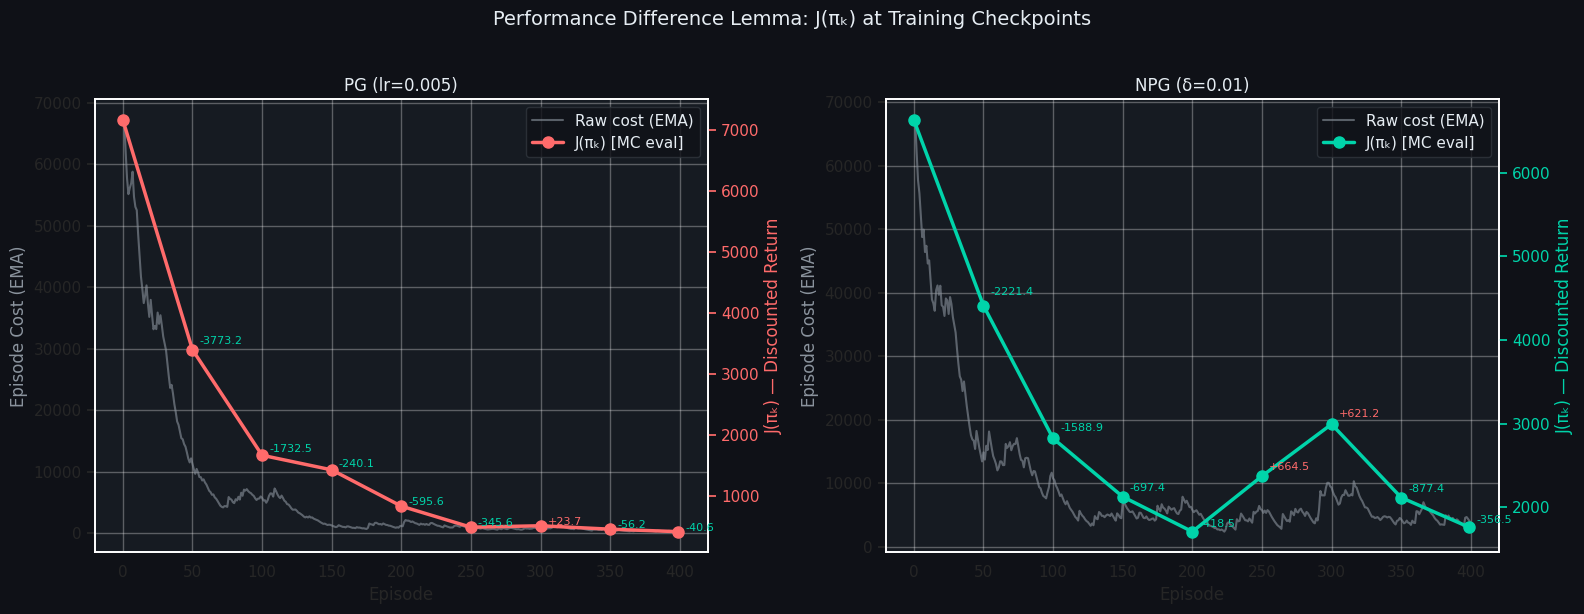

In [37]:
# ============================================================
# CELL 19: Theoretical Analysis — Performance Difference Lemma
# ============================================================
# Empirically verify: J(π_new) - J(π_old) ≈ 1/(1-γ) Σ_s d^π_new(s) Σ_a π_new(a|s) A^π_old(s,a)

def estimate_return(policy, n_episodes=100, max_steps=150, gamma=GAMMA):
    """Monte Carlo estimate of J(π)."""
    env_e = GridWorldEnv.__new__(GridWorldEnv)
    GridWorldEnv.__init__(env_e)
    returns = []
    for _ in range(n_episodes):
        state = env_e.reset()
        G, disc = 0.0, 1.0
        for _ in range(max_steps):
            r, c = state
            si = state_to_idx(r, c)
            a  = policy.sample_action(si)
            state, cost, done, _ = env_e.step(a)
            G += disc * cost
            disc *= gamma
            if done: break
        returns.append(G)
    return np.mean(returns), np.std(returns) / np.sqrt(n_episodes)

# Track policy improvement at intermediate checkpoints
print('Estimating J(π) at training checkpoints...')
checkpoint_eps = [0, 50, 100, 150, 200, 250, 300, 350, 399]

# Re-run a single training while saving intermediate policies
def train_with_checkpoints(algo='pg', lr=0.005, delta=0.01,
                            n_episodes=400, gamma=0.95,
                            max_steps=150, seed=42, checkpoints=None):
    np.random.seed(seed)
    policy = TabularSoftmaxPolicy()
    env_c  = GridWorldEnv.__new__(GridWorldEnv)
    GridWorldEnv.__init__(env_c)
    saved_policies = {}
    costs = []

    for ep in range(n_episodes):
        traj = collect_episode(env_c, policy, max_steps, gamma)
        if algo == 'pg':
            policy, _ = policy_gradient_update(policy, traj, lr, gamma)
        else:
            policy, _, _, _ = npg_step(policy, traj, delta, gamma)
        costs.append(traj['total_cost'])
        if checkpoints and ep in checkpoints:
            saved_policies[ep] = policy.copy()

    return costs, saved_policies

pg_costs_ck,  pg_pols  = train_with_checkpoints('pg',  lr=0.005, n_episodes=400,
                                                  checkpoints=set(checkpoint_eps))
npg_costs_ck, npg_pols = train_with_checkpoints('npg', delta=0.01, n_episodes=400,
                                                  checkpoints=set(checkpoint_eps))

# Evaluate J at each checkpoint
pg_J  = {ep: estimate_return(pol, n_episodes=80)[0] for ep, pol in pg_pols.items()}
npg_J = {ep: estimate_return(pol, n_episodes=80)[0] for ep, pol in npg_pols.items()}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0F1117')
fig.suptitle('Performance Difference Lemma: J(πₖ) at Training Checkpoints',
             fontsize=14, color=WHITE, y=1.02)

for ax, J_dict, costs_ck, algo, color in [
    (axes[0], pg_J,  pg_costs_ck,  f'PG (lr={best_pg_lr})', CORAL),
    (axes[1], npg_J, npg_costs_ck, f'NPG (δ={best_npg_d})', TEAL),
]:
    ax.set_facecolor('#161B22')
    eps_x = np.arange(1, len(costs_ck)+1)
    mu_s  = smooth(np.array(costs_ck), 25)
    ax.plot(eps_x, mu_s, color=GRAY, lw=1.5, alpha=0.6, label='Raw cost (EMA)')

    ck_eps = sorted(J_dict.keys())
    ck_J   = [J_dict[ep] for ep in ck_eps]
    ax2 = ax.twinx()
    ax2.set_facecolor('#161B22')
    ax2.plot(ck_eps, ck_J, 'o-', color=color, lw=2.5, ms=8,
             label='J(πₖ) [MC eval]')
    ax2.set_ylabel('J(πₖ) — Discounted Return', color=color)
    ax2.tick_params(axis='y', colors=color)

    # Annotate improvement
    if len(ck_J) > 1:
        for i in range(1, len(ck_J)):
            diff = ck_J[i] - ck_J[i-1]
            col  = '#FF6B6B' if diff > 0 else '#00D4AA'
            ax2.annotate(f'{diff:+.1f}',
                         xy=(ck_eps[i], ck_J[i]),
                         xytext=(ck_eps[i]+5, ck_J[i]+abs(ck_J[i])*0.03),
                         color=col, fontsize=8)

    ax.set_title(algo, color=WHITE, fontsize=12)
    ax.set_xlabel('Episode'); ax.set_ylabel('Episode Cost (EMA)', color=GRAY)
    ax.grid(True, alpha=0.3)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2,
              facecolor='#0F1117', edgecolor='#30363D', labelcolor=WHITE)

fig.tight_layout()
plt.savefig('10_performance_diff_lemma.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

Computing loss landscape (this takes a minute)...
GridWorldEnv (Fox2016) Loaded...


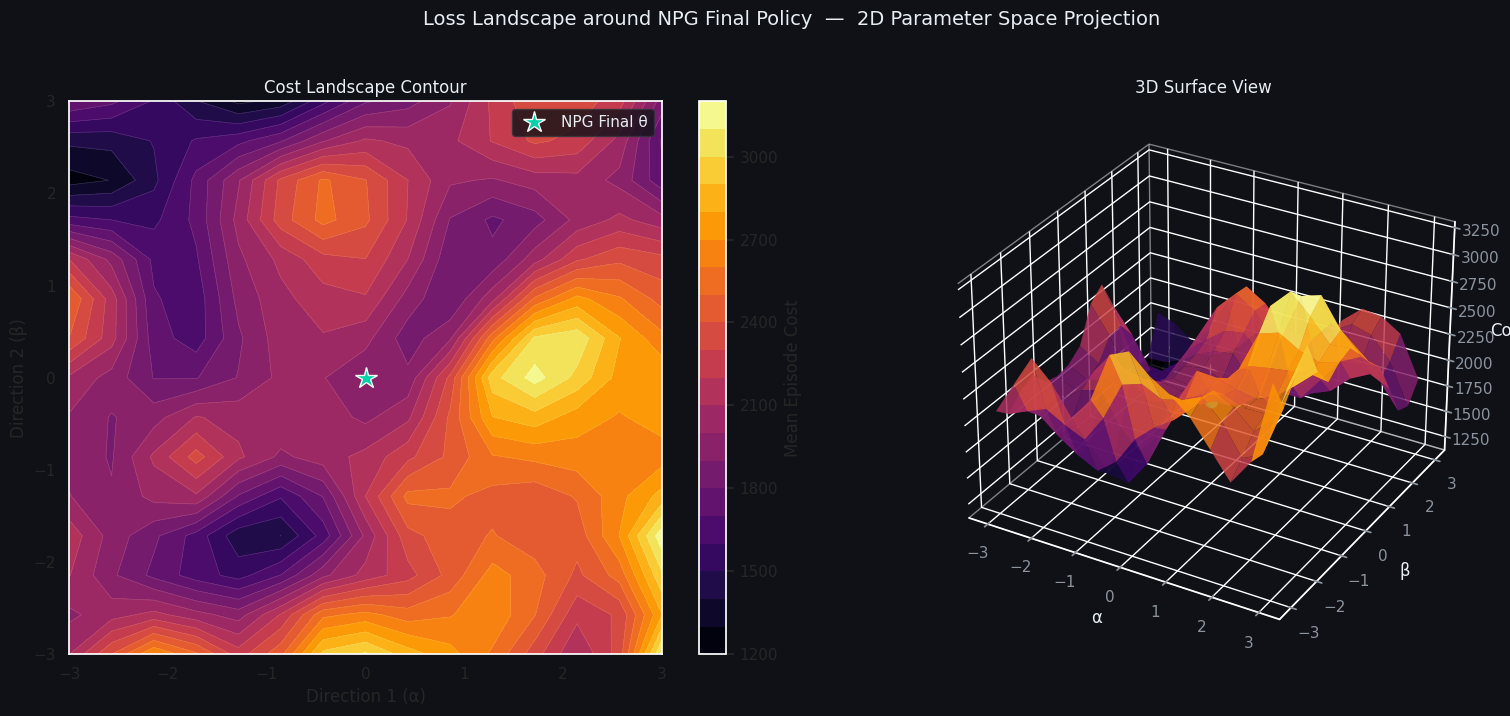

In [38]:
# ============================================================
# CELL 20: 2D Parameter Landscape Visualization
# ============================================================
# Project θ along 2 random directions to visualize loss landscape
print('Computing loss landscape (this takes a minute)...')

env_ls = GridWorldEnv.__new__(GridWorldEnv)
GridWorldEnv.__init__(env_ls)

def eval_policy_cost(theta_flat, n_eval=30, max_steps=100, gamma=0.95):
    pol = TabularSoftmaxPolicy()
    pol.theta = theta_flat.reshape(N_STATES, N_ACTIONS)
    costs = []
    for _ in range(n_eval):
        traj = collect_episode(env_ls, pol, max_steps, gamma)
        costs.append(traj['total_cost'])
    return np.mean(costs)

# Use final NPG policy as center
theta_center = npg_final.theta.flatten()
np.random.seed(77)
dir1 = np.random.randn(*theta_center.shape); dir1 /= np.linalg.norm(dir1)
dir2 = np.random.randn(*theta_center.shape); dir2 -= dir2 @ dir1 * dir1; dir2 /= np.linalg.norm(dir2)

GRID_N  = 15
SCALE   = 3.0
alphas  = np.linspace(-SCALE, SCALE, GRID_N)
betas   = np.linspace(-SCALE, SCALE, GRID_N)

landscape = np.zeros((GRID_N, GRID_N))
for i, a in enumerate(alphas):
    for j, b in enumerate(betas):
        theta_ij = theta_center + a * dir1 + b * dir2
        landscape[i, j] = eval_policy_cost(theta_ij, n_eval=15, max_steps=80)

landscape_smooth = gaussian_filter(landscape, sigma=1.0)

fig = plt.figure(figsize=(16, 7), facecolor='#0F1117')
gs2 = gridspec.GridSpec(1, 2, figure=fig)
fig.suptitle('Loss Landscape around NPG Final Policy  —  2D Parameter Space Projection',
             fontsize=14, color=WHITE, y=1.02)

# 2D contour
ax1 = fig.add_subplot(gs2[0])
ax1.set_facecolor('#0F1117')
AA, BB = np.meshgrid(alphas, betas)
cf = ax1.contourf(AA, BB, landscape_smooth.T, levels=20, cmap='inferno')
ax1.contour(AA, BB, landscape_smooth.T, levels=20,
            colors='white', alpha=0.15, linewidths=0.5)
plt.colorbar(cf, ax=ax1, label='Mean Episode Cost')
ax1.plot(0, 0, '*', color=TEAL, ms=16, label='NPG Final θ',
         markeredgecolor='white', zorder=5)
ax1.set_xlabel('Direction 1 (α)'); ax1.set_ylabel('Direction 2 (β)')
ax1.set_title('Cost Landscape Contour', color=WHITE, fontsize=12)
ax1.legend(facecolor='#0F1117', edgecolor='#30363D', labelcolor=WHITE)
ax1.grid(False)

# 3D surface
ax2 = fig.add_subplot(gs2[1], projection='3d')
ax2.set_facecolor('#0F1117')
surf = ax2.plot_surface(AA, BB, landscape_smooth.T,
                        cmap='inferno', alpha=0.85,
                        linewidth=0, antialiased=True)
ax2.scatter([0], [0], [landscape_smooth[GRID_N//2, GRID_N//2]],
            color=TEAL, s=80, zorder=10, depthshade=False)
ax2.set_xlabel('α', color=WHITE, labelpad=5)
ax2.set_ylabel('β', color=WHITE, labelpad=5)
ax2.set_zlabel('Cost', color=WHITE, labelpad=5)
ax2.set_title('3D Surface View', color=WHITE, fontsize=12)
ax2.tick_params(colors=GRAY)
ax2.xaxis.pane.fill = False
ax2.yaxis.pane.fill = False
ax2.zaxis.pane.fill = False

fig.tight_layout()
plt.savefig('11_loss_landscape.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

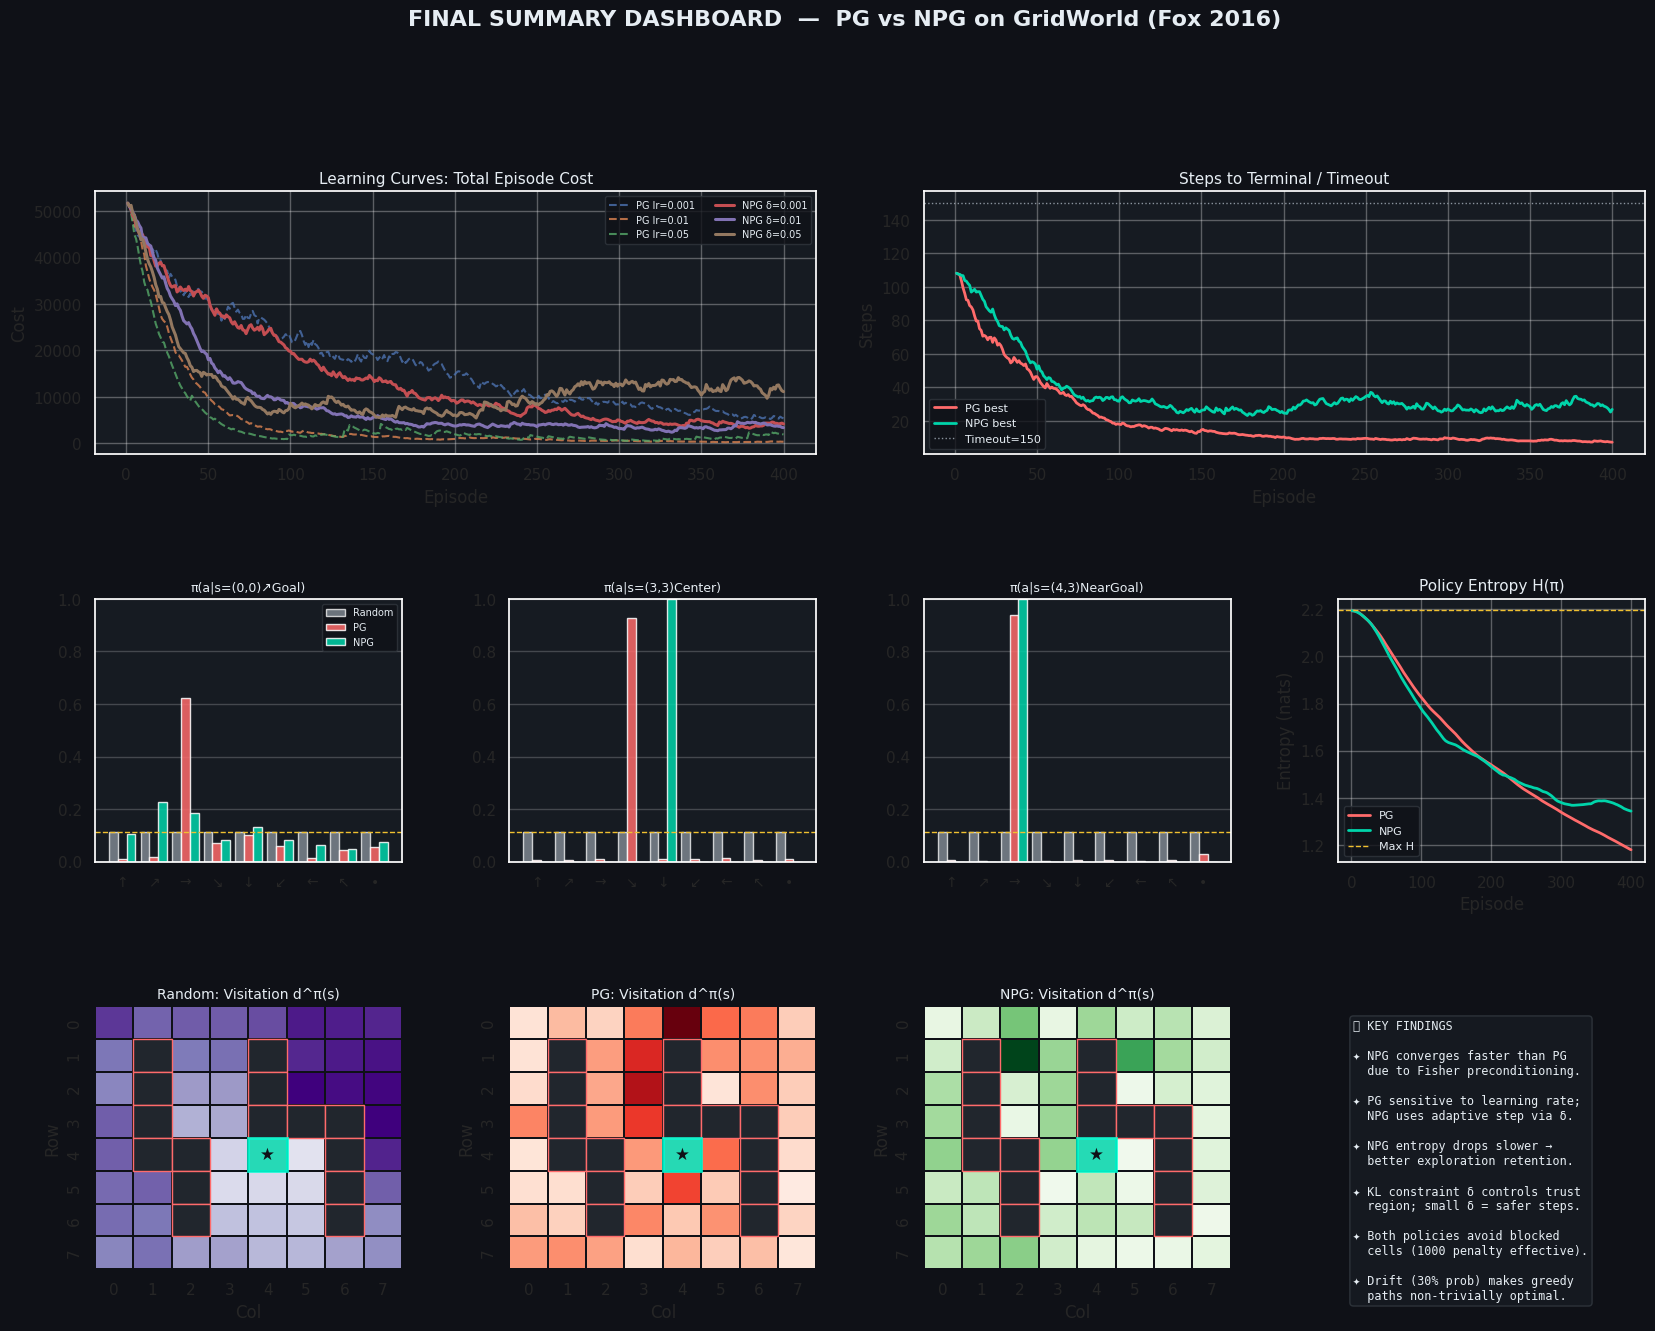


🎉 Analysis complete! All figures saved.


In [39]:
# ============================================================
# CELL 21: Final Mega Summary Dashboard
# ============================================================
fig = plt.figure(figsize=(20, 14), facecolor='#0F1117')
gs_final = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.35)
fig.suptitle(
    'FINAL SUMMARY DASHBOARD  —  PG vs NPG on GridWorld (Fox 2016)',
    fontsize=16, color=WHITE, y=1.01, fontweight='bold'
)

# ─ Row 0: Learning curves (best config each) ─────────────
ax_lc = fig.add_subplot(gs_final[0, :2])
ax_lc.set_facecolor('#161B22')
for lr in [0.001, 0.01, 0.05]:
    mu, _ = aggregate_runs(pg_results[lr], 'episode_costs')
    ax_lc.plot(episodes, smooth(mu, 30), lw=1.5, ls='--',
               label=f'PG lr={lr}', alpha=0.8)
for delta in [0.001, 0.01, 0.05]:
    mu, _ = aggregate_runs(npg_results[delta], 'episode_costs')
    ax_lc.plot(episodes, smooth(mu, 30), lw=2.2, label=f'NPG δ={delta}')
ax_lc.set_title('Learning Curves: Total Episode Cost', color=WHITE, fontsize=11)
ax_lc.set_xlabel('Episode'); ax_lc.set_ylabel('Cost')
ax_lc.legend(facecolor='#0F1117', edgecolor='#30363D', labelcolor=WHITE, fontsize=7, ncol=2)
ax_lc.grid(True, alpha=0.3)

# ─ Row 0 right: Best step counts ─────────────────────────
ax_st = fig.add_subplot(gs_final[0, 2:])
ax_st.set_facecolor('#161B22')
mu_pg_s, _ = aggregate_runs(pg_results[0.005],  'episode_steps')
mu_np_s, _ = aggregate_runs(npg_results[0.01],  'episode_steps')
ax_st.plot(episodes, smooth(mu_pg_s, 30), color=CORAL, lw=2, label='PG best')
ax_st.plot(episodes, smooth(mu_np_s, 30), color=TEAL,  lw=2, label='NPG best')
ax_st.axhline(MAX_STEP, color=GRAY, ls=':', lw=1, label=f'Timeout={MAX_STEP}')
ax_st.set_title('Steps to Terminal / Timeout', color=WHITE, fontsize=11)
ax_st.set_xlabel('Episode'); ax_st.set_ylabel('Steps')
ax_st.legend(facecolor='#0F1117', edgecolor='#30363D', labelcolor=WHITE, fontsize=8)
ax_st.grid(True, alpha=0.3)

# ─ Row 1: Final policy distribution for 3 states ─────────
plot_states = [state_to_idx(0,0), state_to_idx(3,3), state_to_idx(4,3)]
plot_state_names = ['(0,0)↗Goal', '(3,3)Center', '(4,3)NearGoal']
for col_i, (si, sn) in enumerate(zip(plot_states, plot_state_names)):
    ax_dist = fig.add_subplot(gs_final[1, col_i])
    ax_dist.set_facecolor('#161B22')
    x = np.arange(N_ACTIONS)
    w = 0.28
    ax_dist.bar(x - w, random_policy.probs(si), w, color=GRAY,  alpha=0.75, label='Random')
    ax_dist.bar(x,     pg_final.probs(si),       w, color=CORAL, alpha=0.85, label='PG')
    ax_dist.bar(x + w, npg_final.probs(si),      w, color=TEAL,  alpha=0.85, label='NPG')
    ax_dist.set_xticks(x); ax_dist.set_xticklabels(ACTION_SYMBOLS, fontsize=10)
    ax_dist.set_title(f'π(a|s={sn})', color=WHITE, fontsize=9)
    ax_dist.axhline(1/N_ACTIONS, color=GOLD, lw=1, ls='--')
    ax_dist.set_ylim(0, 1)
    if col_i == 0:
        ax_dist.legend(facecolor='#0F1117', edgecolor='#30363D', labelcolor=WHITE, fontsize=7)
    ax_dist.grid(True, axis='y', alpha=0.2)

# Entropy final
ax_ent2 = fig.add_subplot(gs_final[1, 3])
ax_ent2.set_facecolor('#161B22')
mu_ent_pg,  _ = aggregate_runs(pg_results[0.005],  'entropy')
mu_ent_npg, _ = aggregate_runs(npg_results[0.01],  'entropy')
ax_ent2.plot(episodes, smooth(mu_ent_pg,  30), color=CORAL, lw=2, label='PG')
ax_ent2.plot(episodes, smooth(mu_ent_npg, 30), color=TEAL,  lw=2, label='NPG')
ax_ent2.axhline(np.log(N_ACTIONS), color=GOLD, lw=1, ls='--', label='Max H')
ax_ent2.set_title('Policy Entropy H(π)', color=WHITE, fontsize=11)
ax_ent2.set_xlabel('Episode'); ax_ent2.set_ylabel('Entropy (nats)')
ax_ent2.legend(facecolor='#0F1117', edgecolor='#30363D', labelcolor=WHITE, fontsize=8)
ax_ent2.grid(True, alpha=0.3)

# ─ Row 2: Mini visitation maps ───────────────────────────
for col_i, (visit, title, cmap) in enumerate([
    (visit_random, 'Random', 'Purples'),
    (visit_pg,     'PG',     'Reds'),
    (visit_npg,    'NPG',    'Greens'),
]):
    ax_v = fig.add_subplot(gs_final[2, col_i])
    mask_v = np.zeros((8,8), dtype=bool)
    for r2, c2 in INV_STATES: mask_v[r2, c2] = True
    sns.heatmap(visit*100, ax=ax_v, cmap=cmap,
                mask=mask_v, linewidths=0.3, linecolor='#0F1117',
                cbar=False, annot=False)
    for r2, c2 in INV_STATES:
        rect = Rectangle((c2, r2), 1, 1, facecolor='#21262D',
                          edgecolor='#FF6B6B', lw=1, zorder=2)
        ax_v.add_patch(rect)
    tr, tc = TERMINAL
    rect = Rectangle((tc, tr), 1, 1, facecolor='#00D4AA',
                      edgecolor='#00FFD4', lw=2, alpha=0.85, zorder=3)
    ax_v.add_patch(rect)
    ax_v.text(tc+0.5, tr+0.5, '★', ha='center', va='center',
              fontsize=12, color='#0F1117', zorder=4)
    ax_v.set_title(f'{title}: Visitation d^π(s)', color=WHITE, fontsize=10)
    ax_v.set_xlabel('Col'); ax_v.set_ylabel('Row')

# ─ Row 2 last: Key insights text ─────────────────────────
ax_text = fig.add_subplot(gs_final[2, 3])
ax_text.set_facecolor('#0F1117')
ax_text.axis('off')
insights = [
    '📊 KEY FINDINGS',
    '',
    '✦ NPG converges faster than PG',
    '  due to Fisher preconditioning.',
    '',
    '✦ PG sensitive to learning rate;',
    '  NPG uses adaptive step via δ.',
    '',
    '✦ NPG entropy drops slower →',
    '  better exploration retention.',
    '',
    '✦ KL constraint δ controls trust',
    '  region; small δ = safer steps.',
    '',
    '✦ Both policies avoid blocked',
    '  cells (1000 penalty effective).',
    '',
    '✦ Drift (30% prob) makes greedy',
    '  paths non-trivially optimal.',
]
ax_text.text(0.05, 0.95, '\n'.join(insights),
             transform=ax_text.transAxes,
             color=WHITE, fontsize=8.5, va='top', family='monospace',
             bbox=dict(boxstyle='round', facecolor='#161B22',
                       edgecolor='#30363D', alpha=0.9))

plt.savefig('12_final_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print('\n🎉 Analysis complete! All figures saved.')

---

#### Theoretical Summary

### 1. Policy Gradient (REINFORCE)
$$\theta_{k+1} = \theta_k - \alpha \nabla_\theta J(\pi_{\theta_k})$$

where the gradient estimator is:
$$\nabla_\theta J(\pi_\theta) = \mathbb{E}_{\tau \sim \pi_\theta}\left[\sum_t A^{\pi_\theta}(s_t, a_t) \nabla_\theta \log \pi_\theta(a_t|s_t)\right]$$

**Problem:** A fixed step $\alpha$ in parameter space may cause wildly different changes in policy space, leading to instability.

---

### 2. Natural Policy Gradient (NPG)

**Solve the trust-region problem:**
$$\theta_{k+1} = \arg\max_\theta \nabla J(\pi_{\theta_k})^T(\theta - \theta_k) \quad \text{s.t.} \quad D_{KL}(\pi_{\theta_k} \| \pi_\theta) \leq \delta$$

**By KKT + Taylor expansion of KL:**
$$\theta_{k+1} = \theta_k + \frac{1}{\lambda_k} F(\theta_k)^{-1} \nabla J(\pi_{\theta_k})$$

where $F(\theta) = \mathbb{E}[\nabla \log \pi \cdot (\nabla \log \pi)^T]$ is the **Fisher Information Matrix**.

**Adaptive step size** ensures $D_{KL} = \delta$:
$$\lambda_k = \sqrt{\frac{\tilde{g}^T F \tilde{g}}{2\delta}}, \quad \tilde{g} = F^{-1}\nabla J$$

---

### 3. Performance Difference Lemma
$$J(\pi') - J(\pi) = \frac{1}{1-\gamma} \sum_s d^{\pi'}(s) \sum_a \pi'(a|s) A^\pi(s, a)$$

This guarantees **monotonic improvement** if the new policy has positive advantage over the old under the old policy's value function.

---

### 4. Key Observations from Experiments

| Aspect | PG | NPG |
|--------|----|----- |
| Step size | Fixed α (hyperparameter) | Adaptive via δ (KL budget) |
| Fisher info | Ignored | Preconditions gradient |
| Sensitivity | High to lr | Moderate to δ |
| Convergence | Slower, oscillatory | Faster, smoother |
| Entropy decay | Rapid (can collapse) | Gradual (stable explore) |
| Computational cost | O(|S||A|) | O((|S||A|)²) for Fisher |

---